### Dalex [Explainable AI]

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import dalex as dx
import keras.models as km
import keras

In [2]:
data = pd.read_csv("Dataset/trace4_dataset.csv", header = 0, names = ['Unnamed: 0', 'timestamp', 'type', 'collection_id', 'priority', 
                                                                    'resource_request.cpus', 'resource_request.memory', 'collection_type', 
                                                                    'vertical_scaling', 'scheduler', 'assigned_memory', 'cpu_usage', 'power_consumption'])

In [3]:
data = data.drop('Unnamed: 0', 1)

C:\Users\luqsa\AppData\Local\Temp/ipykernel_11316/2038751425.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  data = data.drop('Unnamed: 0', 1)


In [4]:
data.shape

(1000000, 12)

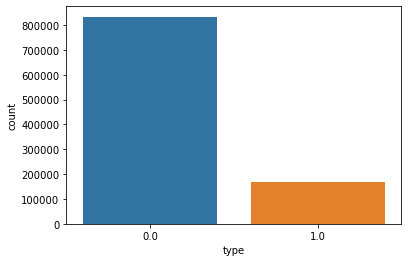

In [5]:
sns.countplot(data=data, x='type')
plt.show()

In [6]:
trace_data = pd.DataFrame(data)

In [7]:
trace_data.head()

,timestamp,type,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption
0,1000000.0,1.0,4.588266e+11,1.0,0.416916,2.259689,0.0,1.0,1.0,0.015625,0.0,87.0
1,1000000.0,1.0,4.588266e+11,1.0,0.416916,2.259689,0.0,1.0,1.0,0.015625,0.0,87.0
2,1000000.0,1.0,4.588266e+11,1.0,0.416916,2.259689,0.0,1.0,1.0,0.015625,0.0,87.0
3,1000000.0,1.0,4.588266e+11,1.0,0.416916,2.259689,0.0,1.0,1.0,0.015625,0.0,87.0
4,1000000.0,1.0,4.588266e+11,1.0,0.416916,2.259689,0.0,1.0,1.0,0.015625,0.0,87.0


In [8]:
trace_data.tail(10)

,timestamp,type,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption
999990,1000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.001596,87.178144
999991,15000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.001272,87.142449
999992,18000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.045525,91.513540
999993,65000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.068336,93.571941
999994,4000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.174927,102.239930
999995,162000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.129639,98.717181
999996,138000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.160950,101.174498
999997,2000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.001474,87.164726
999998,2000000.0,0.0,5.016183e+11,0.0,0.937478,0.411742,0.0,2.0,0.0,0.002804,0.001665,87.185681
999999,87000000.0,0.0,2.809728e+11,0.0,-0.023126,0.003504,0.0,2.0,0.0,0.001780,0.001167,87.130862


In [9]:
#Y = trace_data['type'].to_numpy()
#X = trace_data.drop(['type', 'timestamp'], axis = 1).to_numpy()
X, Y = trace_data.drop(['type', 'timestamp'], axis = 1), trace_data.type

In [10]:
print('Features Shape', X.shape)
print('Labels Shape', Y.shape)

Features Shape (1000000, 10)
Labels Shape (1000000,)


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [12]:
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(sampling_strategy='majority')

In [13]:
X_train_RUS, Y_train_RUS = undersample.fit_resample(X_train, Y_train)

<AxesSubplot:>

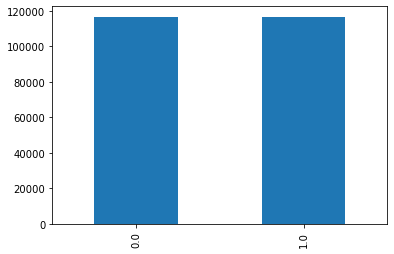

In [14]:
pd.Series(Y_train_RUS).value_counts().plot.bar()

In [15]:
X_test_RUS, Y_test_RUS = undersample.fit_resample(X_test, Y_test)

<AxesSubplot:>

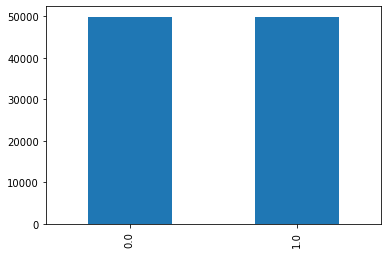

In [16]:
pd.Series(Y_test_RUS).value_counts().plot.bar()

#### Imbalanced Data Model Fit - Random Oversampling

In [17]:
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority')

In [18]:
X_train_ROS, Y_train_ROS = oversample.fit_resample(X_train, Y_train)

<AxesSubplot:>

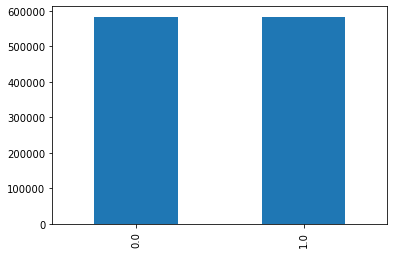

In [19]:
pd.Series(Y_train_ROS).value_counts().plot.bar()

In [20]:
X_test_ROS, Y_test_ROS = oversample.fit_resample(X_test, Y_test)

<AxesSubplot:>

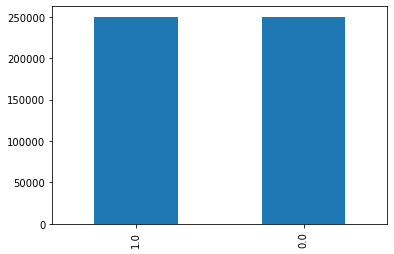

In [21]:
pd.Series(Y_test_ROS).value_counts().plot.bar()

#### Imbalanced Data Model Fit - SMOTE

In [22]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 33)

In [23]:
X_train_SMOTE, Y_train_SMOTE = oversample.fit_resample(X_train, Y_train)

<AxesSubplot:>

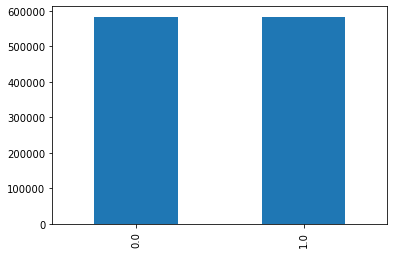

In [24]:
pd.Series(Y_train_SMOTE).value_counts().plot.bar()

In [25]:
X_test_SMOTE, Y_test_SMOTE = oversample.fit_resample(X_test, Y_test)

<AxesSubplot:>

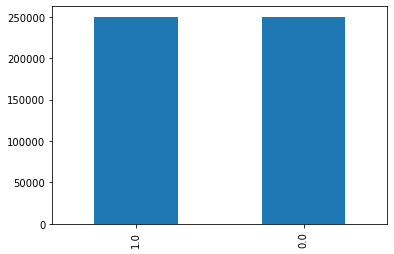

In [26]:
pd.Series(Y_test_SMOTE).value_counts().plot.bar()

In [27]:
Y.shape

(1000000,)

In [28]:
import warnings
warnings.filterwarnings('ignore')

#### Without Imbalaced Handling

##### Logistic Regression

In [96]:
LR_train = joblib.load('Jobs/WIB/LogReg.model')
exp_LR_train = dx.Explainer(LR_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 3.86e-06, mean = 0.167, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 5.43e-05, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [97]:
exp_LR_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.552033,0.819509,0.659689,0.905099,0.827367


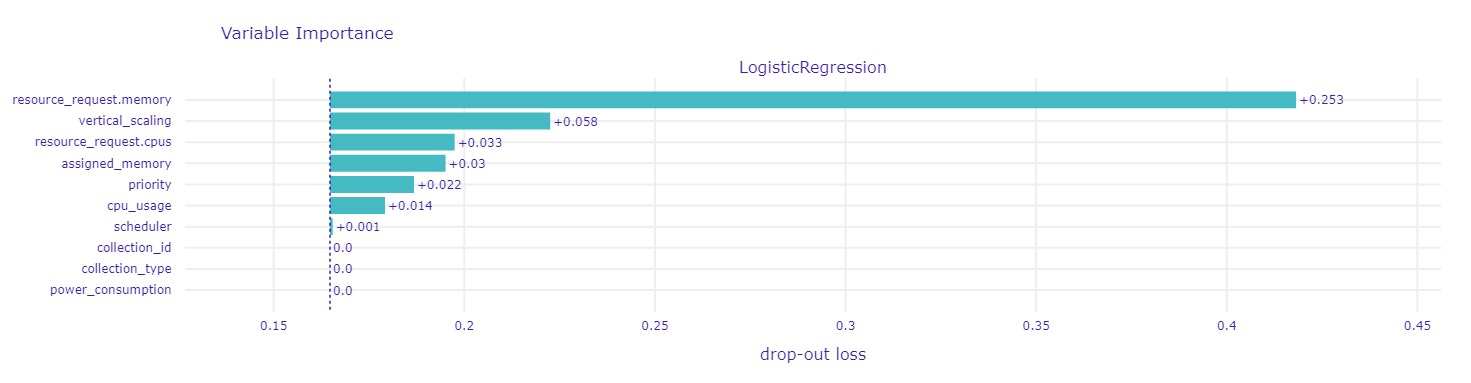

In [98]:
explanation_LR_train = exp_LR_train.model_parts()
explanation_LR_train.result
explanation_LR_train.plot()

In [99]:
exp_LR_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.022867,-0.022867,0.022867,LogisticRegression,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.806349,0.193651,0.193651,LogisticRegression,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.047274,-0.047274,0.047274,LogisticRegression,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.047289,-0.047289,0.047289,LogisticRegression,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.176978,-0.176978,0.176978,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.028524,-0.028524,0.028524,LogisticRegression,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.174843,-0.174843,0.174843,LogisticRegression,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.006687,0.993313,0.993313,LogisticRegression,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.047372,-0.047372,0.047372,LogisticRegression,699999


In [100]:
LR_test = joblib.load('Jobs/WIB/LogReg.model')
exp_LR_test = dx.Explainer(LR_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 9.85e-06, mean = 0.166, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.000363, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [101]:
exp_LR_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.548631,0.817902,0.656737,0.904513,0.824931


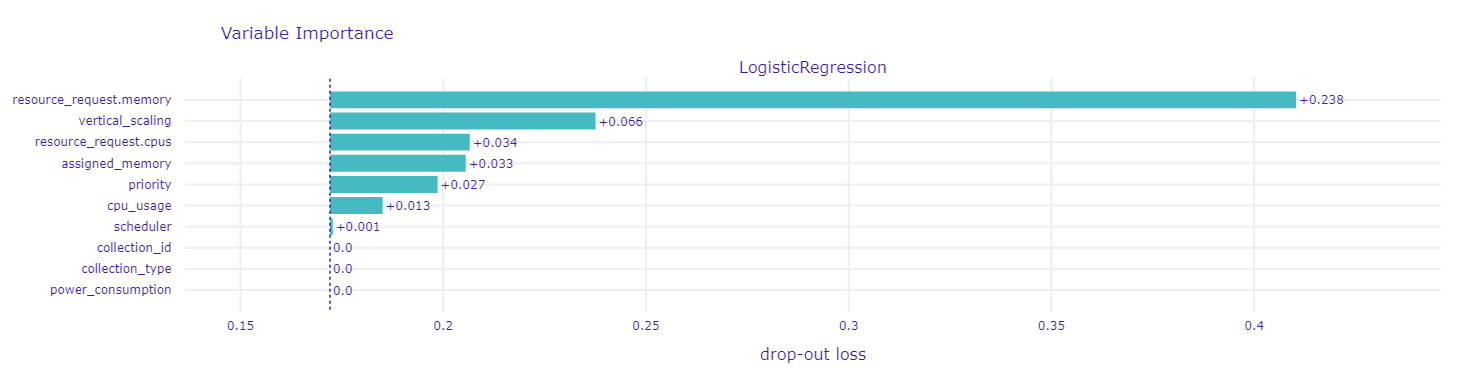

In [102]:
explanation_LR_test = exp_LR_test.model_parts()
explanation_LR_test.result
explanation_LR_test.plot()

In [103]:
exp_LR_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.013016,0.986984,0.986984,LogisticRegression,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.010385,0.989615,0.989615,LogisticRegression,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.047280,-0.047280,0.047280,LogisticRegression,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.022869,-0.022869,0.022869,LogisticRegression,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.182125,-0.182125,0.182125,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.222090,-0.222090,0.222090,LogisticRegression,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.046757,-0.046757,0.046757,LogisticRegression,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.026834,-0.026834,0.026834,LogisticRegression,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.027013,-0.027013,0.027013,LogisticRegression,299999


##### Decision Tree

In [104]:
DT_train = joblib.load('Jobs/WIB/DecisionTreeClassifier.model')
exp_DT_train = dx.Explainer(DT_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0393, mean = 0.167, max = 0.863
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.863, mean = 4.48e-05, max = 0.961
  -> model_info        : package sklearn

A new explainer has been created!


In [105]:
exp_DT_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.800828,0.863345,0.830912,0.945691,0.887742


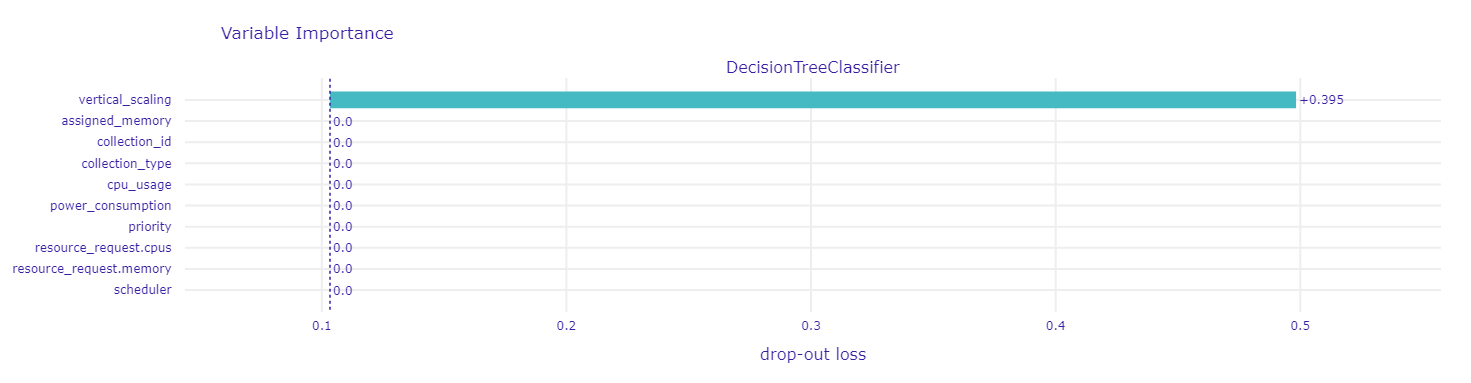

In [106]:
explanation_DR_train = exp_DT_train.model_parts()
explanation_DR_train.result
explanation_DR_train.plot()

In [107]:
exp_DT_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.862635,0.137365,0.137365,DecisionTreeClassifier,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.039331,0.960669,0.960669,DecisionTreeClassifier,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,699999


In [108]:
DT_test = joblib.load('Jobs/WIB/DecisionTreeClassifier.model')
exp_DT_test = dx.Explainer(DT_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0393, mean = 0.166, max = 0.863
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.863, mean = 0.000843, max = 0.961
  -> model_info        : package sklearn

A new explainer has been created!


In [109]:
exp_DT_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.796128,0.863912,0.828636,0.945177,0.885539


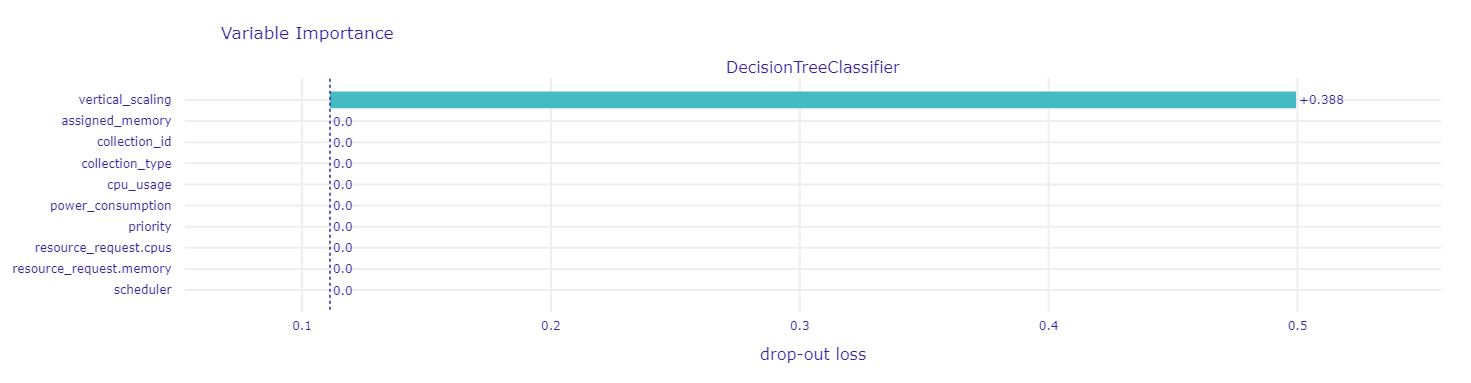

In [110]:
explanation_DT_test = exp_DT_test.model_parts()
explanation_DT_test.result
explanation_DT_test.plot()

In [111]:
exp_DT_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.039331,0.960669,0.960669,DecisionTreeClassifier,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.039331,0.960669,0.960669,DecisionTreeClassifier,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.039331,-0.039331,0.039331,DecisionTreeClassifier,299999


##### Random Forest

In [112]:
RF_train = joblib.load('Jobs/WIB/RandomForestClassifier.model')
exp_RF_train = dx.Explainer(RF_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.085, mean = 0.167, max = 0.803
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.802, mean = -1.67e-05, max = 0.914
  -> model_info        : package sklearn

A new explainer has been created!


In [113]:
exp_RF_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.406283,0.989807,0.576097,0.900374,0.909768


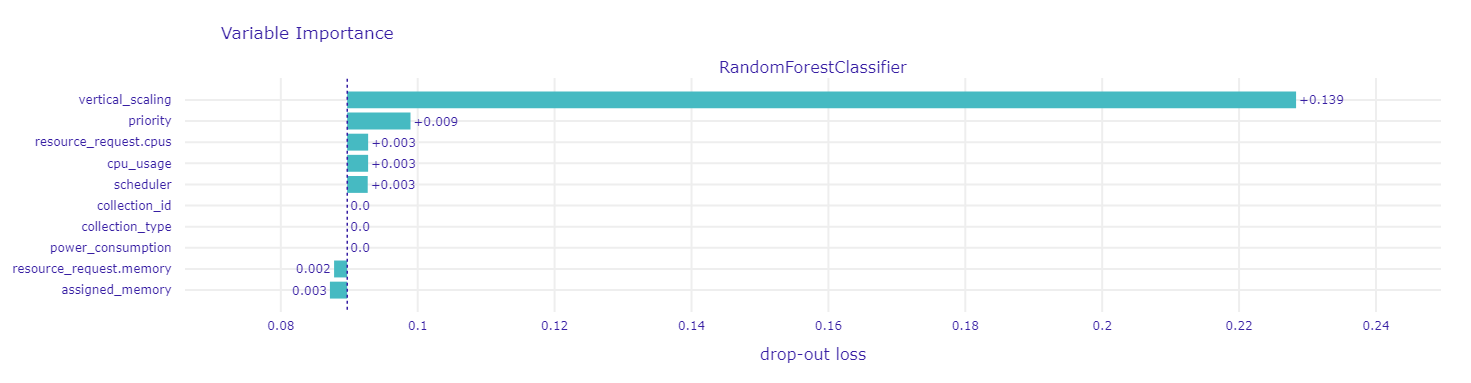

In [114]:
explanation_RF_train = exp_RF_train.model_parts()
explanation_RF_train.result
explanation_RF_train.plot()

In [115]:
exp_RF_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.101782,-0.101782,0.101782,RandomForestClassifier,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.803395,0.196605,0.196605,RandomForestClassifier,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.101782,-0.101782,0.101782,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.101782,0.898218,0.898218,RandomForestClassifier,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,699999


In [116]:
RF_test = joblib.load('Jobs/WIB/RandomForestClassifier.model')
exp_RF_test = dx.Explainer(RF_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.085, mean = 0.166, max = 0.803
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.788, mean = 0.000738, max = 0.914
  -> model_info        : package sklearn

A new explainer has been created!


In [117]:
exp_RF_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.399716,0.989836,0.569469,0.899373,0.909431


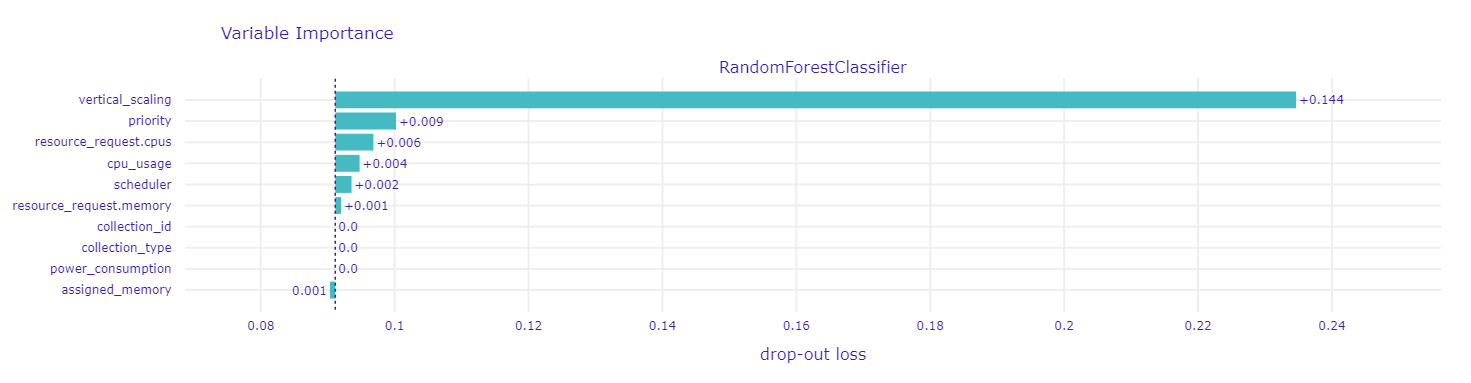

In [118]:
explanation_RF_test = exp_RF_test.model_parts()
explanation_RF_test.result
explanation_RF_test.plot()

In [119]:
exp_RF_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.086059,0.913941,0.913941,RandomForestClassifier,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.101782,0.898218,0.898218,RandomForestClassifier,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.101782,-0.101782,0.101782,RandomForestClassifier,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.086059,-0.086059,0.086059,RandomForestClassifier,299999


##### Gradient Boosting

In [120]:
GB_train = joblib.load('Jobs/WIB/GradientBoostingClassifier.model')
exp_GB_train = dx.Explainer(GB_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0745, mean = 0.171, max = 0.653
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.636, mean = -0.00418, max = 0.926
  -> model_info        : package sklearn

A new explainer has been created!


In [121]:
exp_GB_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.978986,0.942892,0.9606,0.986619,0.996792


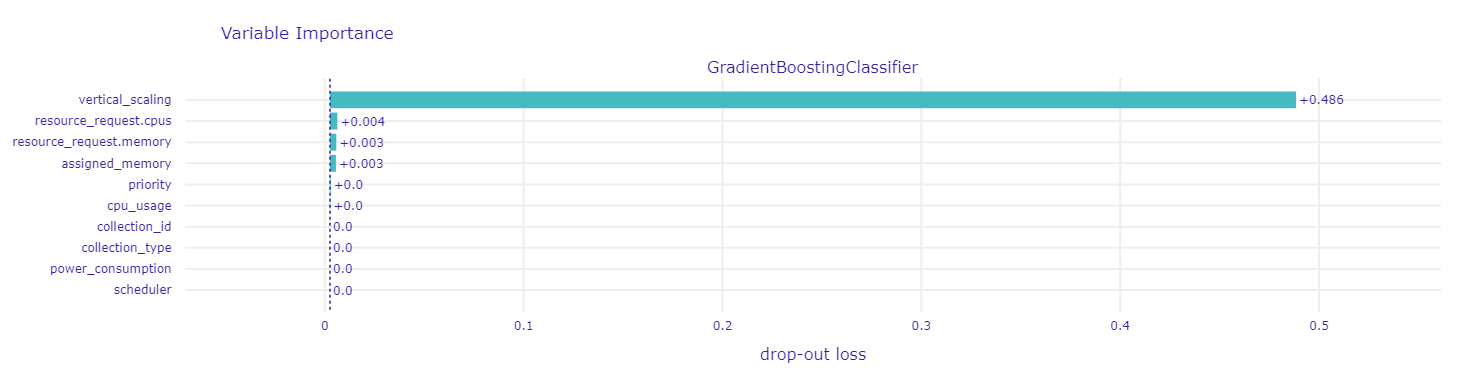

In [122]:
explanation_GB_train = exp_GB_train.model_parts()
explanation_GB_train.result
explanation_GB_train.plot()

In [123]:
exp_GB_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.634984,0.365016,0.365016,GradientBoostingClassifier,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.635547,0.364453,0.364453,GradientBoostingClassifier,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,699999


In [124]:
GB_test = joblib.load('Jobs/WIB/GradientBoostingClassifier.model')
exp_GB_test = dx.Explainer(GB_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0745, mean = 0.171, max = 0.653
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.636, mean = -0.00415, max = 0.926
  -> model_info        : package sklearn

A new explainer has been created!


In [125]:
exp_GB_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.979339,0.942795,0.96072,0.986667,0.996809


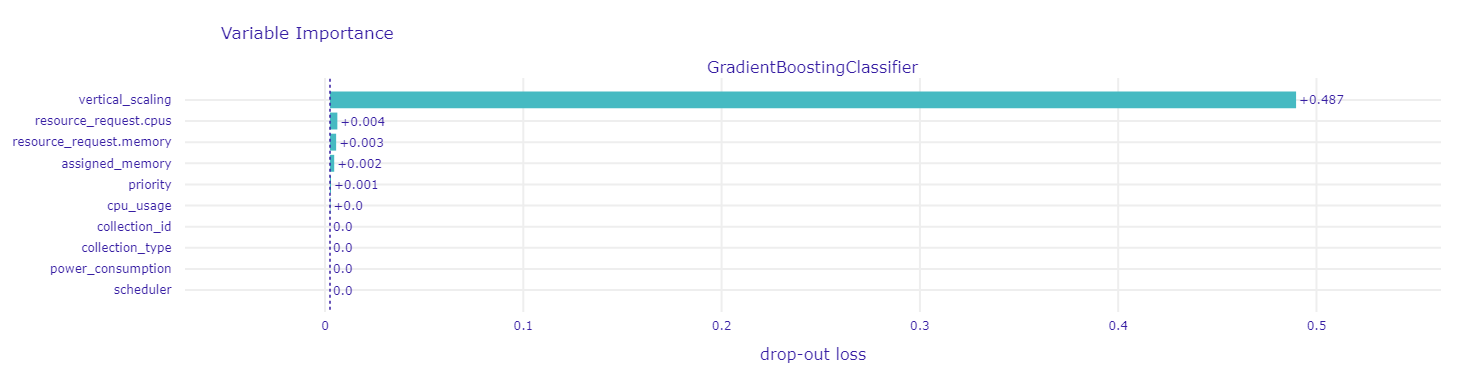

In [126]:
explanation_GB_test = exp_GB_test.model_parts()
explanation_GB_test.result
explanation_GB_test.plot()

In [127]:
exp_GB_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.635547,0.364453,0.364453,GradientBoostingClassifier,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.635547,0.364453,0.364453,GradientBoostingClassifier,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.074462,-0.074462,0.074462,GradientBoostingClassifier,299999


##### Extreme Gradient Boosting

In [128]:
XGB_train = joblib.load('Jobs/WIB/XGBClassifier.model')
exp_XGB_train = dx.Explainer(XGB_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.403, max = 0.646
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.646, mean = -0.236, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [129]:
exp_XGB_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.994633,0.951113,0.972386,0.990587,0.99854


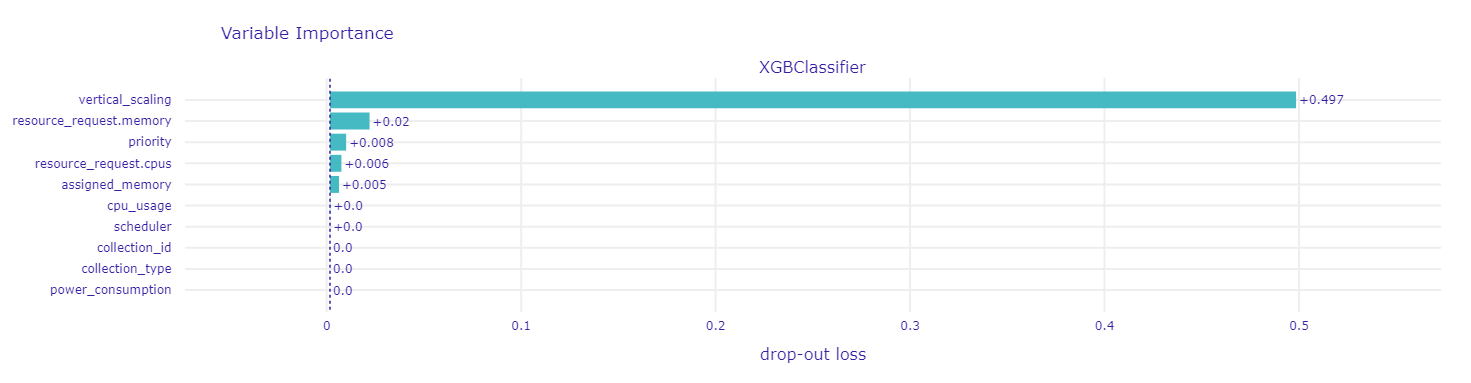

In [130]:
explanation_XGB_train = exp_XGB_train.model_parts()
explanation_XGB_train.result
explanation_XGB_train.plot()

In [131]:
exp_XGB_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.354365,-0.354365,0.354365,XGBClassifier,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.645617,0.354383,0.354383,XGBClassifier,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.354365,-0.354365,0.354365,XGBClassifier,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.354365,-0.354365,0.354365,XGBClassifier,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.354365,-0.354365,0.354365,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.354365,-0.354365,0.354365,XGBClassifier,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.354365,-0.354365,0.354365,XGBClassifier,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.645633,0.354367,0.354367,XGBClassifier,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.354365,-0.354365,0.354365,XGBClassifier,699999


In [132]:
XGB_test = joblib.load('Jobs/WIB/XGBClassifier.model')
exp_XGB_test = dx.Explainer(XGB_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.403, max = 0.646
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.646, mean = -0.236, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [133]:
exp_XGB_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.994554,0.950682,0.972124,0.990503,0.998471


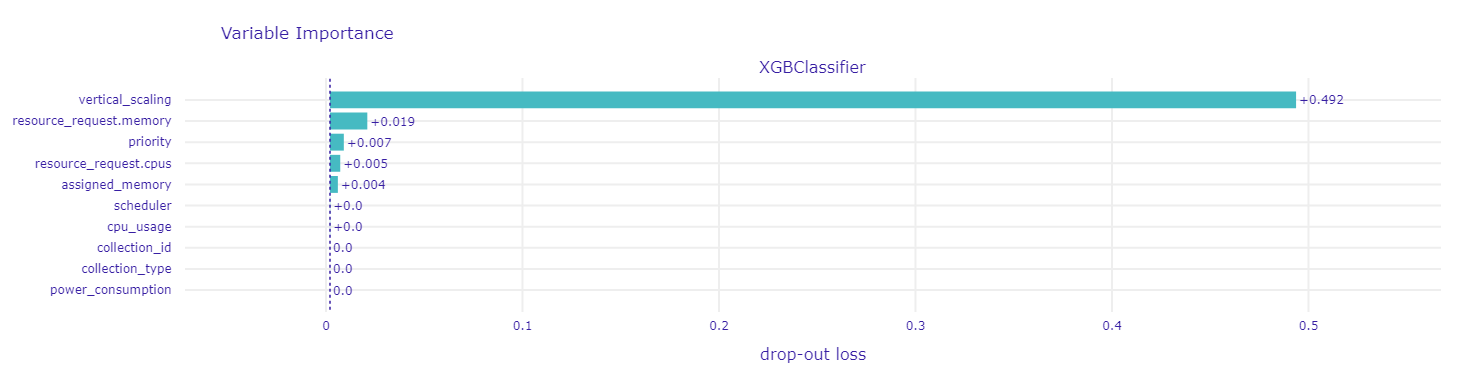

In [134]:
explanation_XGB_test = exp_XGB_test.model_parts()
explanation_XGB_test.result
explanation_XGB_test.plot()

In [135]:
exp_XGB_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.645633,0.354367,0.354367,XGBClassifier,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.645633,0.354367,0.354367,XGBClassifier,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.354365,-0.354365,0.354365,XGBClassifier,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.354365,-0.354365,0.354365,XGBClassifier,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.354365,-0.354365,0.354365,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.354365,-0.354365,0.354365,XGBClassifier,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.354365,-0.354365,0.354365,XGBClassifier,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.354365,-0.354365,0.354365,XGBClassifier,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.354365,-0.354365,0.354365,XGBClassifier,299999


#### With Imbalanced Handling - Using RUS

##### Logistic Regression

In [136]:
LR_RUS_train = joblib.load('Jobs/RUS/LogReg.model')
exp_LR_RUS_train = dx.Explainer(LR_RUS_train, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.00013, mean = 0.5, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 1.31e-05, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [137]:
exp_LR_RUS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.80424,0.83875,0.821133,0.824813,0.913188


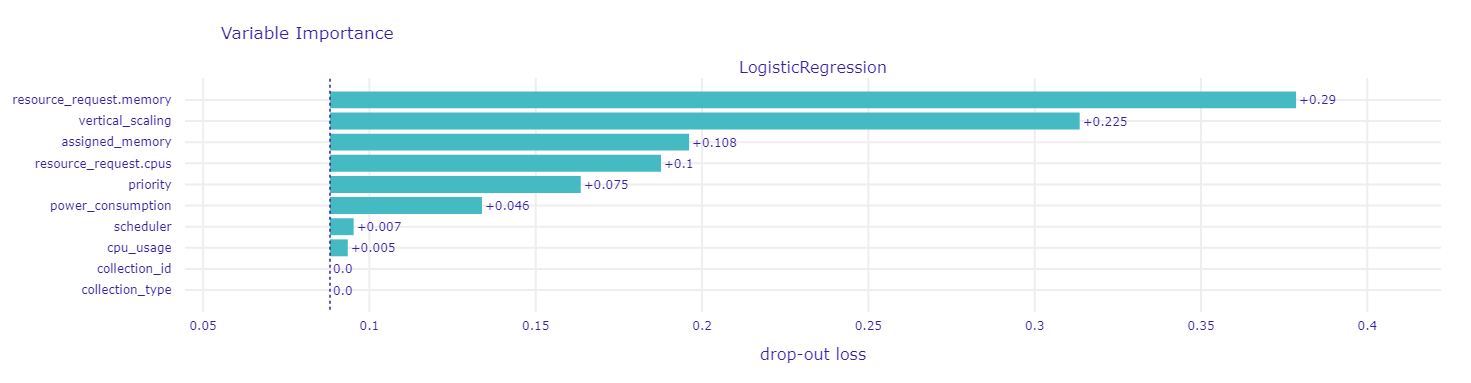

In [138]:
explanation_LR_RUS_train = exp_LR_RUS_train.model_parts()
explanation_LR_RUS_train.result
explanation_LR_RUS_train.plot()

In [139]:
exp_LR_RUS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.128744,-0.128744,0.128744,LogisticRegression,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.130265,-0.130265,0.130265,LogisticRegression,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.128898,-0.128898,0.128898,LogisticRegression,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.129142,-0.129142,0.129142,LogisticRegression,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.128895,-0.128895,0.128895,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.569885,0.430115,0.430115,LogisticRegression,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.960718,0.039282,0.039282,LogisticRegression,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.556629,0.443371,0.443371,LogisticRegression,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.937272,0.062728,0.062728,LogisticRegression,233275


In [140]:
LR_RUS_test = joblib.load('Jobs/RUS/LogReg.model')
exp_LR_RUS_test = dx.Explainer(LR_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 2.59e-05, mean = 0.499, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.00135, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [141]:
exp_LR_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.801714,0.840342,0.820574,0.824698,0.912738


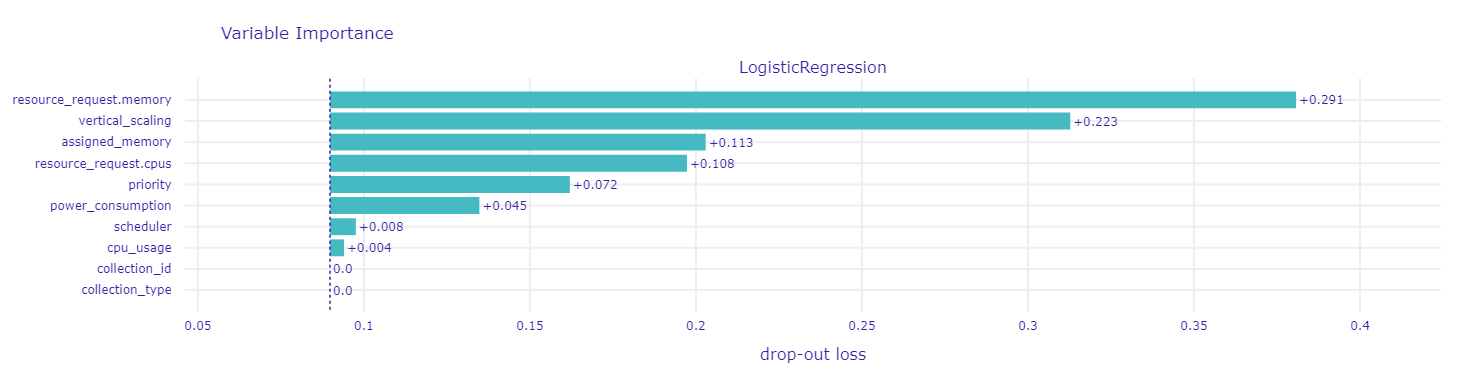

In [142]:
explanation_LR_RUS_test = exp_LR_RUS_test.model_parts()
explanation_LR_RUS_test.result
explanation_LR_RUS_test.plot()

In [143]:
exp_LR_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.129972,-0.129972,0.129972,LogisticRegression,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.129031,-0.129031,0.129031,LogisticRegression,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.129807,-0.129807,0.129807,LogisticRegression,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.130257,-0.130257,0.130257,LogisticRegression,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.326785,-0.326785,0.326785,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.726934,0.273066,0.273066,LogisticRegression,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.269273,0.730727,0.730727,LogisticRegression,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.799560,0.200440,0.200440,LogisticRegression,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.947994,0.052006,0.052006,LogisticRegression,99895


##### Decision Tree

In [144]:
DT_RUS_train = joblib.load('Jobs/RUS/DecisionTreeClassifier.model')
exp_DT_RUS_train = dx.Explainer(DT_RUS_train, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.17, mean = 0.5, max = 0.969
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = 0.000225, max = 0.83
  -> model_info        : package sklearn

A new explainer has been created!


In [145]:
exp_DT_RUS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.800828,0.970261,0.87744,0.888141,0.888141


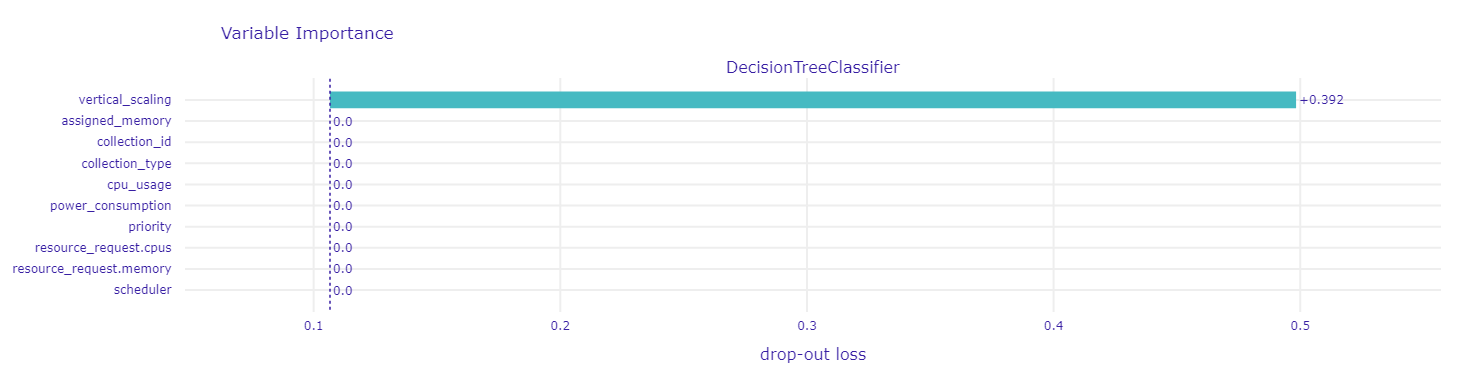

In [146]:
explanation_DT_RUS_train = exp_DT_RUS_train.model_parts()
explanation_DT_RUS_train.result
explanation_DT_RUS_train.plot()

In [147]:
exp_DT_RUS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,233275


In [148]:
DT_RUS_test = joblib.load('Jobs/RUS/DecisionTreeClassifier.model')
exp_DT_RUS_test = dx.Explainer(DT_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.17, mean = 0.498, max = 0.969
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = 0.00178, max = 0.83
  -> model_info        : package sklearn

A new explainer has been created!


In [149]:
exp_DT_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.796128,0.969145,0.874158,0.885391,0.885391


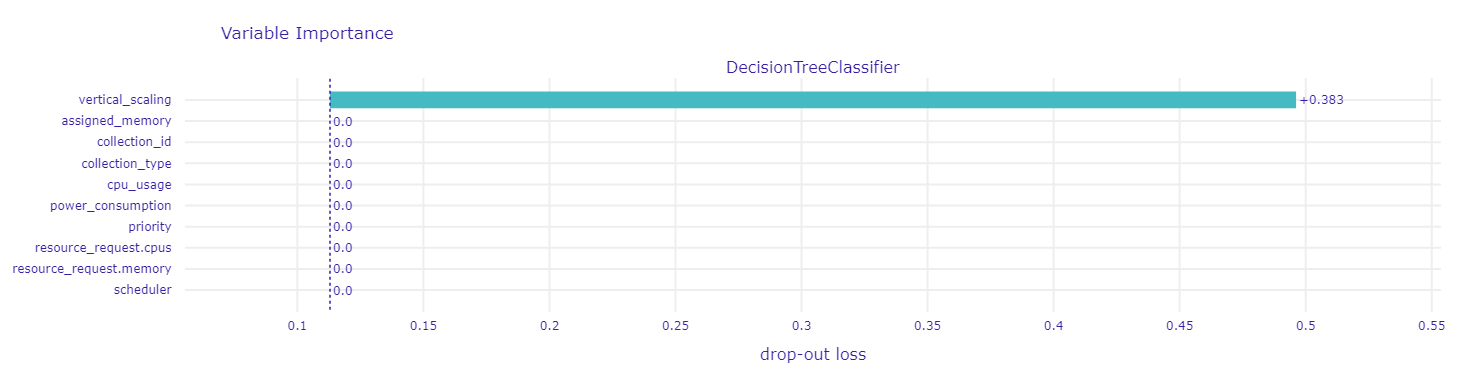

In [150]:
explanation_DT_RUS_test = exp_DT_RUS_test.model_parts()
explanation_DT_RUS_test.result
explanation_DT_RUS_test.plot()

In [151]:
exp_DT_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.170097,-0.170097,0.170097,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.170097,0.829903,0.829903,DecisionTreeClassifier,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.968954,0.031046,0.031046,DecisionTreeClassifier,99895


##### Random Forest

In [152]:
RF_RUS_train = joblib.load('Jobs/RUS/RandomForestClassifier.model')
exp_RF_RUS_train = dx.Explainer(RF_RUS_train, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.242, mean = 0.5, max = 0.885
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.885, mean = 0.000337, max = 0.756
  -> model_info        : package sklearn

A new explainer has been created!


In [153]:
exp_RF_RUS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.82372,0.841872,0.832697,0.834501,0.900813


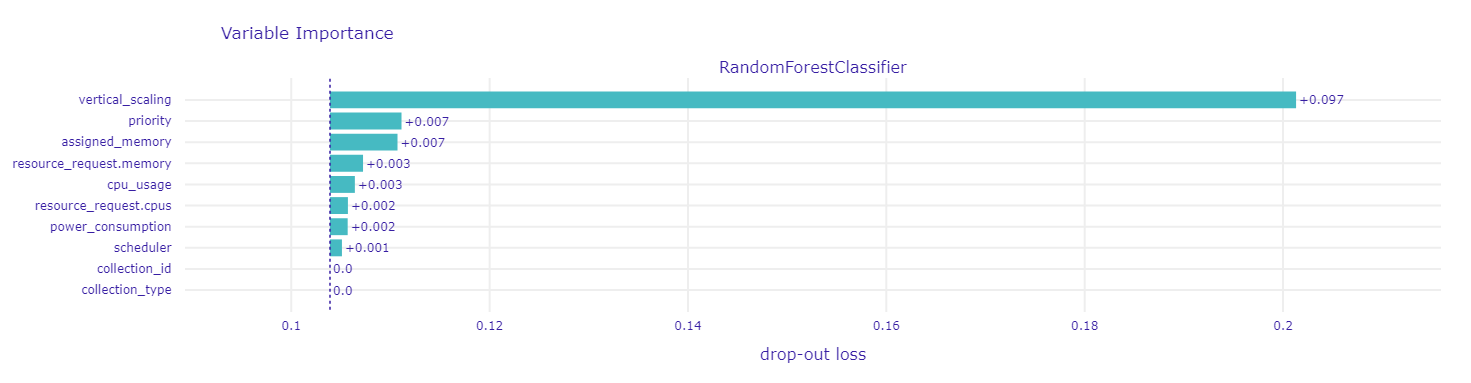

In [154]:
explanation_RF_RUS_train = exp_RF_RUS_train.model_parts()
explanation_RF_RUS_train.result
explanation_RF_RUS_train.plot()

In [155]:
exp_RF_RUS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.851453,0.148547,0.148547,RandomForestClassifier,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.859646,0.140354,0.140354,RandomForestClassifier,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.825871,0.174129,0.174129,RandomForestClassifier,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.795793,0.204207,0.204207,RandomForestClassifier,233275


In [156]:
RF_RUS_test = joblib.load('Jobs/RUS/RandomForestClassifier.model')
exp_RF_RUS_test = dx.Explainer(RF_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.242, mean = 0.499, max = 0.885
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.885, mean = 0.00119, max = 0.756
  -> model_info        : package sklearn

A new explainer has been created!


In [157]:
exp_RF_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.820613,0.839454,0.829927,0.831835,0.898964


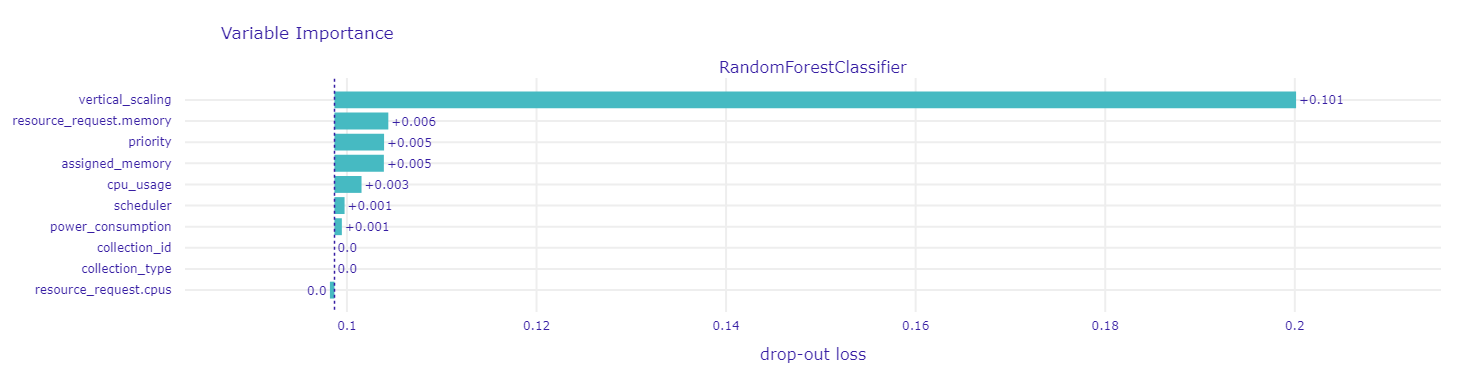

In [158]:
explanation_RF_RUS_test = exp_RF_RUS_test.model_parts()
explanation_RF_RUS_test.result
explanation_RF_RUS_test.plot()

In [159]:
exp_RF_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.244452,-0.244452,0.244452,RandomForestClassifier,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.506631,-0.506631,0.506631,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.533615,0.466385,0.466385,RandomForestClassifier,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.244452,0.755548,0.755548,RandomForestClassifier,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.770212,0.229788,0.229788,RandomForestClassifier,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.885228,0.114772,0.114772,RandomForestClassifier,99895


##### Gradient Boosting

In [160]:
GB_RUS_train = joblib.load('Jobs/RUS/GradientBoostingClassifier.model')
exp_GB_RUS_train = dx.Explainer(GB_RUS_train, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.45, mean = 0.5, max = 0.55
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.549, mean = 3.18e-05, max = 0.55
  -> model_info        : package sklearn

A new explainer has been created!


In [161]:
exp_GB_RUS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.999443,0.980751,0.990008,0.989913,0.992533


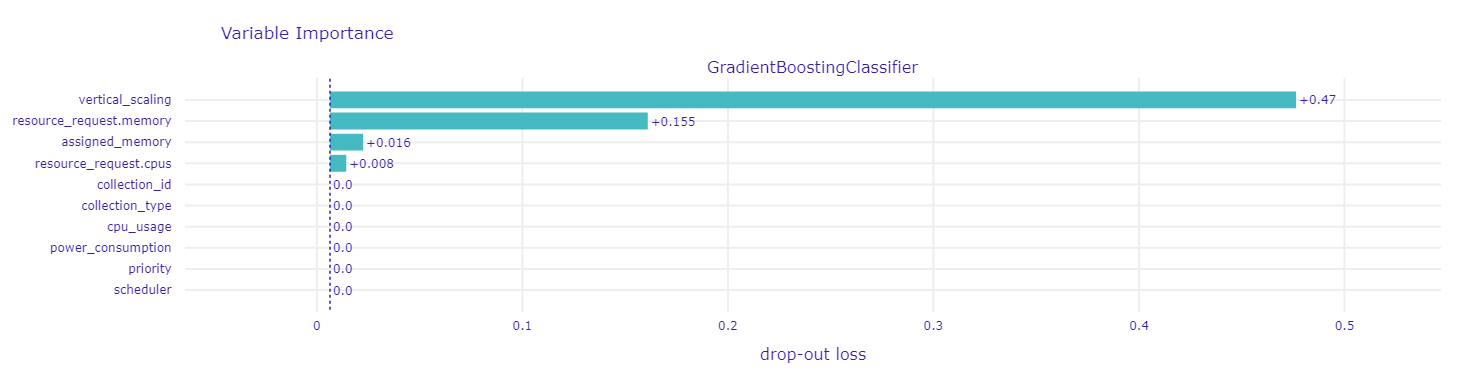

In [162]:
explanation_GB_RUS_train = exp_GB_RUS_train.model_parts()
explanation_GB_RUS_train.result
explanation_GB_RUS_train.plot()

In [163]:
exp_GB_RUS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,233275


In [164]:
GB_RUS_test = joblib.load('Jobs/RUS/GradientBoostingClassifier.model')
exp_GB_RUS_test = dx.Explainer(GB_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.45, mean = 0.5, max = 0.55
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.55, mean = -1.89e-05, max = 0.55
  -> model_info        : package sklearn

A new explainer has been created!


In [165]:
exp_GB_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.999319,0.979782,0.989454,0.989349,0.99226


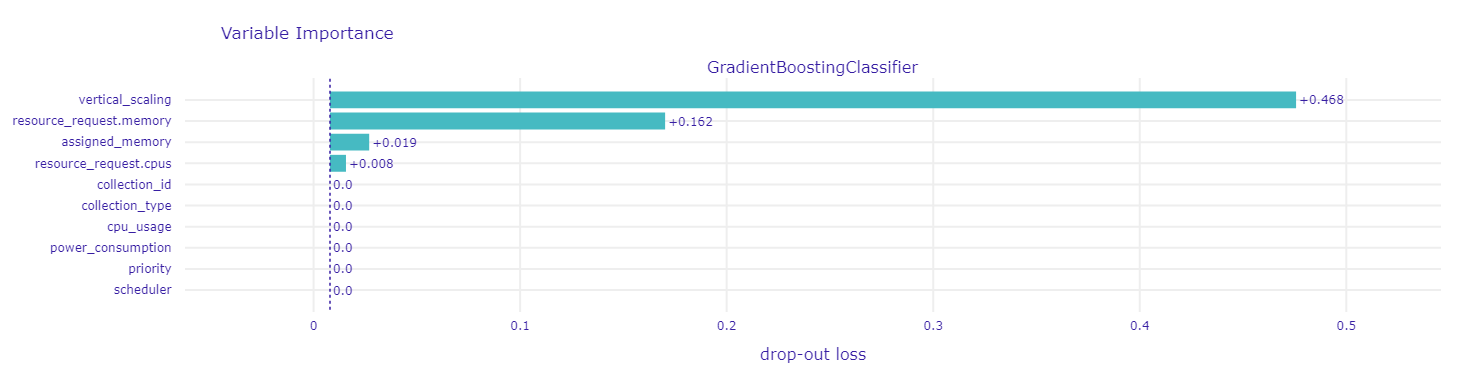

In [166]:
explanation_GB_RUS_test = exp_GB_RUS_test.model_parts()
explanation_GB_RUS_test.result
explanation_GB_RUS_test.plot()

In [167]:
exp_GB_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.450203,-0.450203,0.450203,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.549233,0.450767,0.450767,GradientBoostingClassifier,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.547897,0.452103,0.452103,GradientBoostingClassifier,99895


##### Extreme Gradient Boosting

In [168]:
XGB_RUS_train = joblib.load('Jobs/RUS/XGBClassifier.model')
exp_XGB_RUS_train = dx.Explainer(XGB_RUS_train, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.5, max = 0.645
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.645, mean = -2.64e-05, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [169]:
exp_XGB_RUS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.999297,0.987386,0.993306,0.993265,0.997477


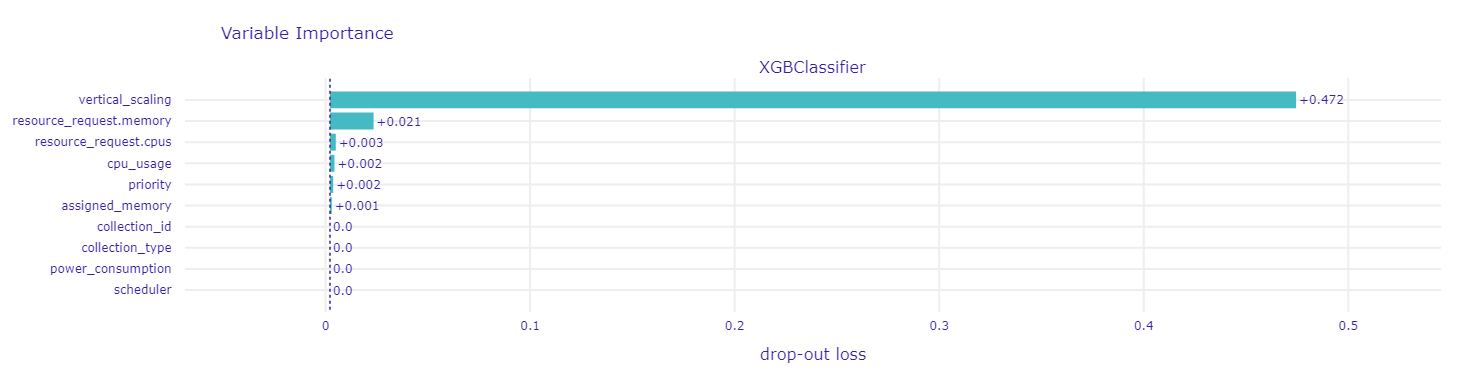

In [170]:
explanation_XGB_RUS_train = exp_XGB_RUS_train.model_parts()
explanation_XGB_RUS_train.result
explanation_XGB_RUS_train.plot()

In [171]:
exp_XGB_RUS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.354380,-0.354380,0.354380,XGBClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.354380,-0.354380,0.354380,XGBClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.354380,-0.354380,0.354380,XGBClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.354380,-0.354380,0.354380,XGBClassifier,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.354380,-0.354380,0.354380,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.645028,0.354972,0.354972,XGBClassifier,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.637022,0.362978,0.362978,XGBClassifier,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.637022,0.362978,0.362978,XGBClassifier,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.645028,0.354972,0.354972,XGBClassifier,233275


In [172]:
XGB_RUS_test = joblib.load('Jobs/RUS/XGBClassifier.model')
exp_XGB_RUS_test = dx.Explainer(XGB_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.5, max = 0.645
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.645, mean = -0.000135, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [173]:
exp_XGB_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.999359,0.986521,0.992899,0.992853,0.997315


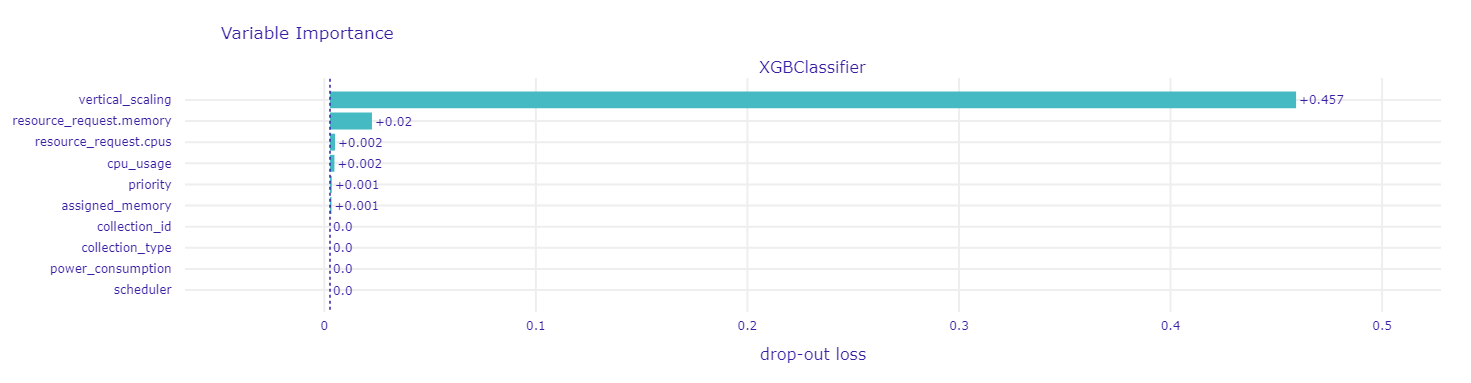

In [174]:
explanation_XGB_RUS_test = exp_XGB_RUS_test.model_parts()
explanation_XGB_RUS_test.result
explanation_XGB_RUS_test.plot()

In [175]:
exp_XGB_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.354380,-0.354380,0.354380,XGBClassifier,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.354380,-0.354380,0.354380,XGBClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.354380,-0.354380,0.354380,XGBClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.354380,-0.354380,0.354380,XGBClassifier,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.354380,-0.354380,0.354380,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.645028,0.354972,0.354972,XGBClassifier,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.645191,0.354809,0.354809,XGBClassifier,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.645028,0.354972,0.354972,XGBClassifier,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.645028,0.354972,0.354972,XGBClassifier,99895


#### With Imbalanced Handling - Using ROS

##### Logistic Regression

In [176]:
LR_ROS_train = joblib.load('Jobs/ROS/LogReg.model')
exp_LR_ROS_train = dx.Explainer(LR_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 8.69e-06, mean = 0.5, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.000268, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [177]:
exp_LR_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.803374,0.837916,0.820282,0.823986,0.912702


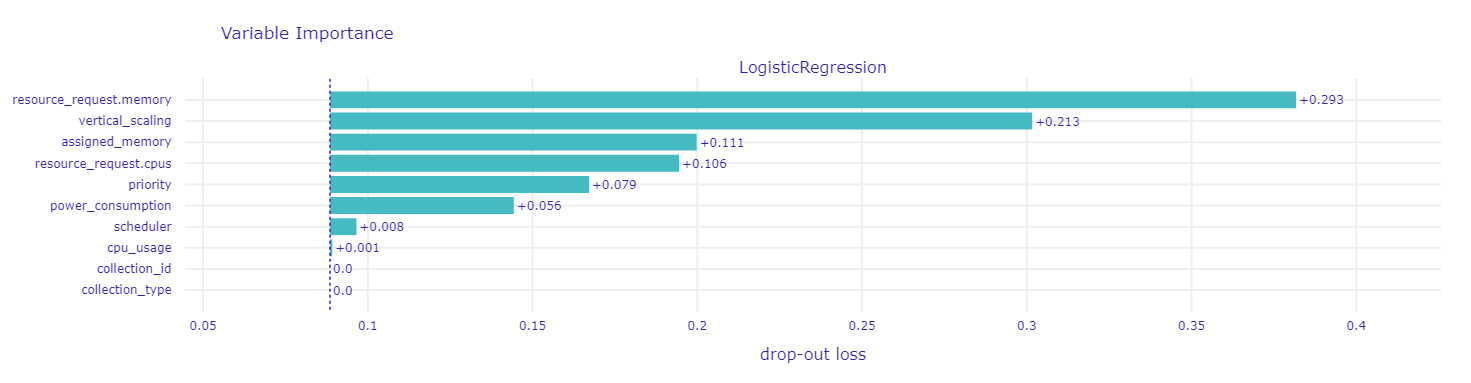

In [178]:
explanation_LR_ROS_train = exp_LR_ROS_train.model_parts()
explanation_LR_ROS_train.result
explanation_LR_ROS_train.plot()

In [179]:
exp_LR_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.012972,-0.012972,0.012972,LogisticRegression,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.944271,0.055729,0.055729,LogisticRegression,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.128311,-0.128311,0.128311,LogisticRegression,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.128326,-0.128326,0.128326,LogisticRegression,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.602842,-0.602842,0.602842,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.946965,0.053035,0.053035,LogisticRegression,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.946932,0.053068,0.053068,LogisticRegression,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.944179,0.055821,0.055821,LogisticRegression,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.944173,0.055827,0.055827,LogisticRegression,1166723


In [180]:
LR_ROS_test = joblib.load('Jobs/ROS/LogReg.model')
exp_LR_ROS_test = dx.Explainer(LR_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 2.5e-05, mean = 0.499, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.00071, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [181]:
exp_LR_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.802377,0.837697,0.819657,0.823459,0.912277


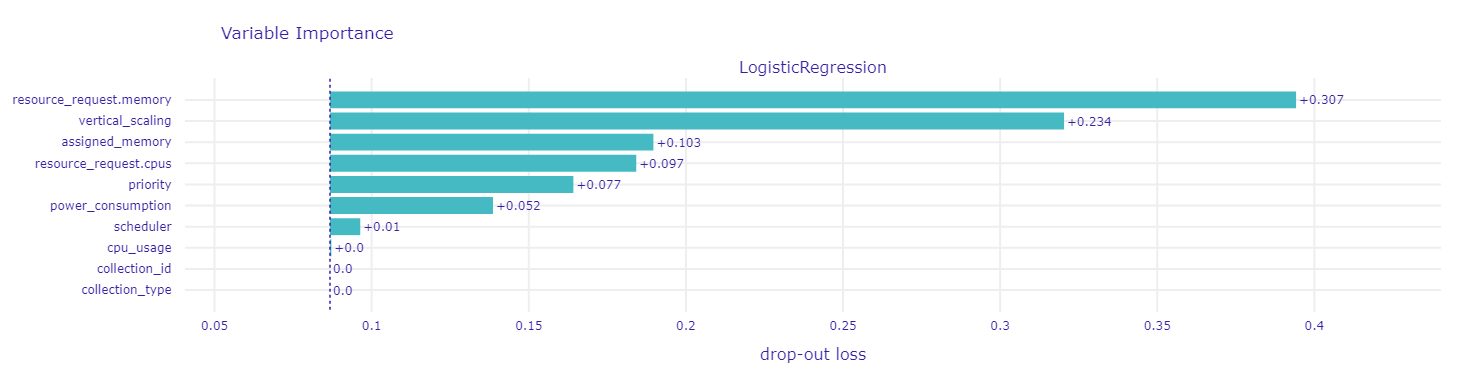

In [182]:
explanation_LR_ROS_test = exp_LR_ROS_test.model_parts()
explanation_LR_ROS_test.result
explanation_LR_ROS_test.plot()

In [183]:
exp_LR_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.236000,0.764000,0.764000,LogisticRegression,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.192282,0.807718,0.807718,LogisticRegression,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.128317,-0.128317,0.128317,LogisticRegression,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.015910,-0.015910,0.015910,LogisticRegression,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.682992,-0.682992,0.682992,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.595939,0.404061,0.404061,LogisticRegression,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.236556,0.763444,0.763444,LogisticRegression,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.946724,0.053276,0.053276,LogisticRegression,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.504437,0.495563,0.495563,LogisticRegression,500103


##### Decision Tree

In [184]:
DT_ROS_train = joblib.load('Jobs/ROS/DecisionTreeClassifier.model')
exp_DT_ROS_train = dx.Explainer(DT_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.17, mean = 0.5, max = 0.969
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = -8.75e-06, max = 0.83
  -> model_info        : package sklearn

A new explainer has been created!


In [185]:
exp_DT_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.800654,0.969317,0.876949,0.887655,0.887655


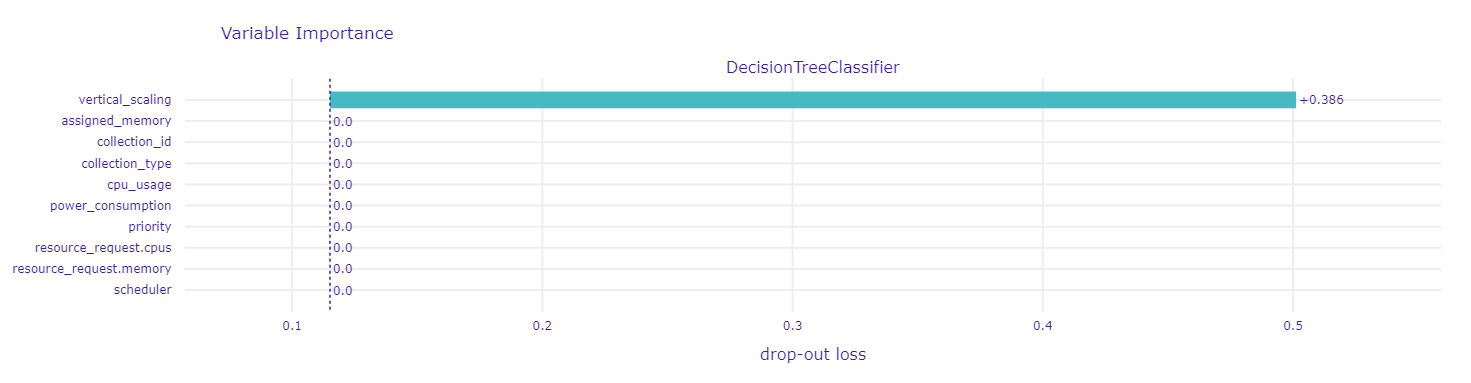

In [186]:
explanation_DT_ROS_train = exp_DT_ROS_train.model_parts()
explanation_DT_ROS_train.result
explanation_DT_ROS_train.plot()

In [187]:
exp_DT_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,1166723


In [188]:
DT_ROS_test = joblib.load('Jobs/ROS/DecisionTreeClassifier.model')
exp_DT_ROS_test = dx.Explainer(DT_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.17, mean = 0.498, max = 0.969
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = 0.00156, max = 0.83
  -> model_info        : package sklearn

A new explainer has been created!


In [189]:
exp_DT_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.79701,0.969527,0.874845,0.88598,0.88598


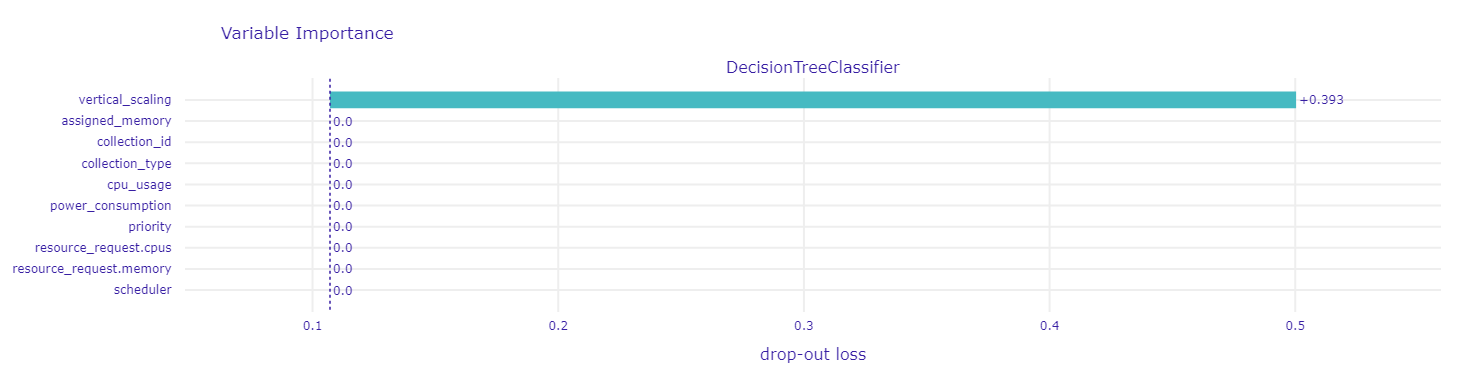

In [190]:
explanation_DT_ROS_test = exp_DT_ROS_test.model_parts()
explanation_DT_ROS_test.result
explanation_DT_ROS_test.plot()

In [191]:
exp_DT_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.169915,0.830085,0.830085,DecisionTreeClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.169915,0.830085,0.830085,DecisionTreeClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.169915,-0.169915,0.169915,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.169915,0.830085,0.830085,DecisionTreeClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.969175,0.030825,0.030825,DecisionTreeClassifier,500103


##### Random Forest

In [192]:
RF_ROS_train = joblib.load('Jobs/ROS/RandomForestClassifier.model')
exp_RF_ROS_train = dx.Explainer(RF_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.244, mean = 0.5, max = 0.898
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.898, mean = 7.97e-06, max = 0.756
  -> model_info        : package sklearn

A new explainer has been created!


In [193]:
exp_RF_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.811985,0.843206,0.827301,0.830498,0.896389


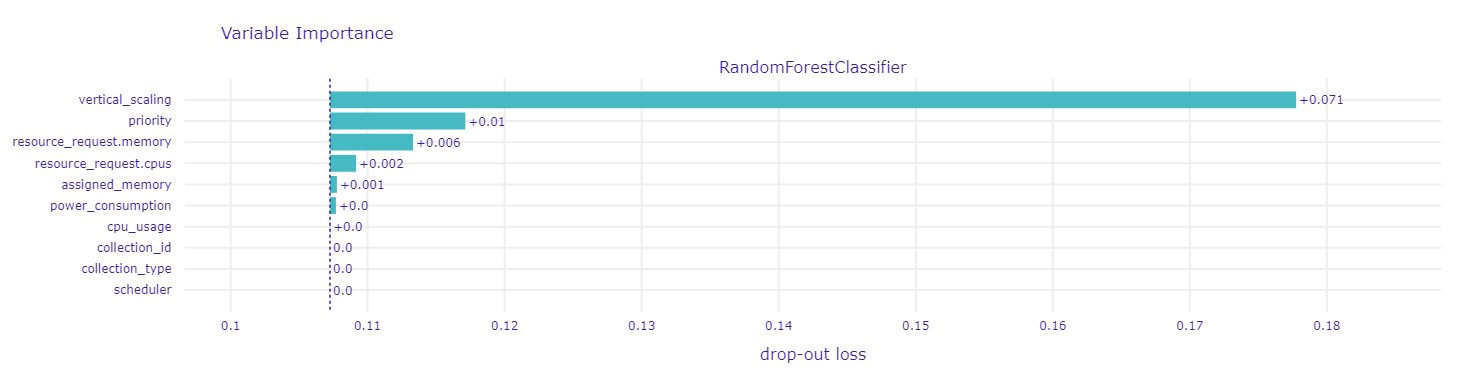

In [194]:
explanation_RF_ROS_train = exp_RF_ROS_train.model_parts()
explanation_RF_ROS_train.result
explanation_RF_ROS_train.plot()

In [195]:
exp_RF_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.264266,-0.264266,0.264266,RandomForestClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.897927,0.102073,0.102073,RandomForestClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.244402,-0.244402,0.244402,RandomForestClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.244402,-0.244402,0.244402,RandomForestClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.264266,-0.264266,0.264266,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.897927,0.102073,0.102073,RandomForestClassifier,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.897927,0.102073,0.102073,RandomForestClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.897927,0.102073,0.102073,RandomForestClassifier,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.897927,0.102073,0.102073,RandomForestClassifier,1166723


In [196]:
RF_ROS_test = joblib.load('Jobs/ROS/RandomForestClassifier.model')
exp_RF_ROS_test = dx.Explainer(RF_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.244, mean = 0.499, max = 0.898
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.898, mean = 0.000929, max = 0.756
  -> model_info        : package sklearn

A new explainer has been created!


In [197]:
exp_RF_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.810431,0.842311,0.826064,0.829355,0.89553


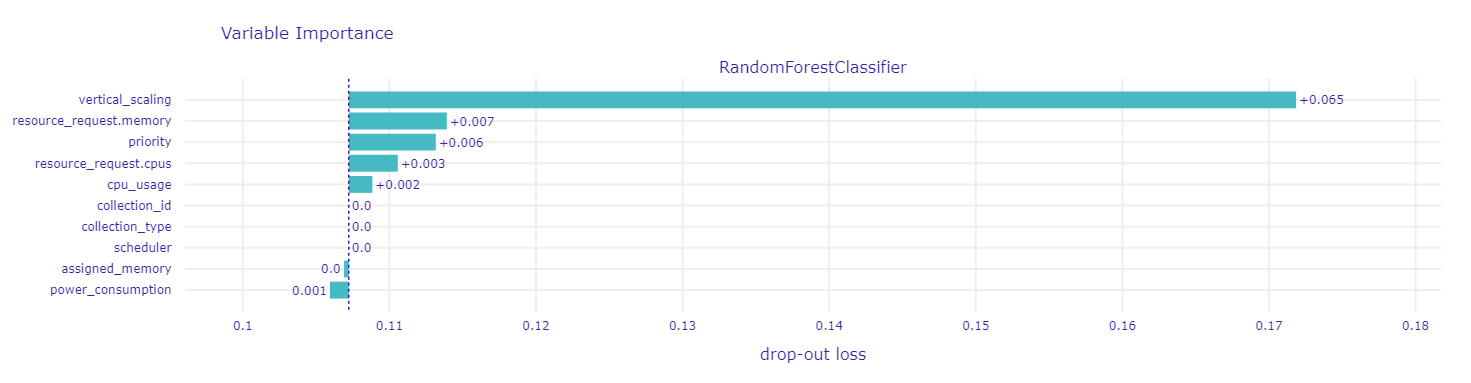

In [198]:
explanation_LR_ROS_test = exp_RF_ROS_test.model_parts()
explanation_LR_ROS_test.result
explanation_LR_ROS_test.plot()

In [199]:
exp_RF_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.244402,0.755598,0.755598,RandomForestClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.264266,0.735734,0.735734,RandomForestClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.244402,-0.244402,0.244402,RandomForestClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.264266,-0.264266,0.264266,RandomForestClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.244402,-0.244402,0.244402,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.773603,0.226397,0.226397,RandomForestClassifier,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.244402,0.755598,0.755598,RandomForestClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.897927,0.102073,0.102073,RandomForestClassifier,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.821830,0.178170,0.178170,RandomForestClassifier,500103


##### Gradient Boosting

In [200]:
GB_ROS_train = joblib.load('Jobs/ROS/GradientBoostingClassifier.model')
exp_GB_ROS_train = dx.Explainer(GB_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.45, mean = 0.5, max = 0.55
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.549, mean = -2.61e-06, max = 0.55
  -> model_info        : package sklearn

A new explainer has been created!


In [201]:
exp_GB_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.999491,0.980073,0.989687,0.989585,0.992319


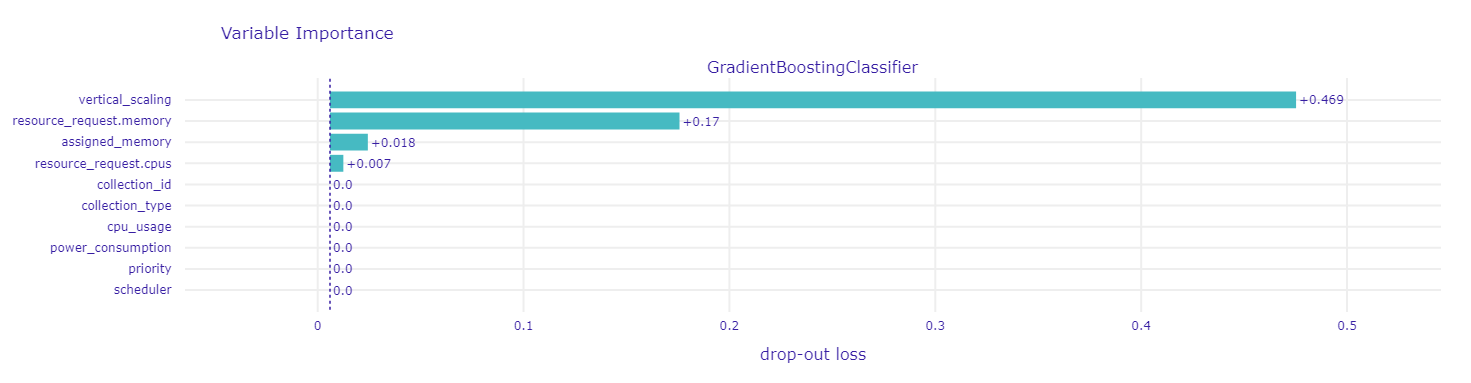

In [202]:
explanation_GB_ROS_train = exp_GB_ROS_train.model_parts()
explanation_GB_ROS_train.result
explanation_GB_ROS_train.plot()

In [203]:
exp_GB_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,1166723


In [204]:
GB_ROS_test = joblib.load('Jobs/ROS/GradientBoostingClassifier.model')
exp_GB_ROS_test = dx.Explainer(GB_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.45, mean = 0.5, max = 0.55
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.549, mean = 5.81e-06, max = 0.55
  -> model_info        : package sklearn

A new explainer has been created!


In [205]:
exp_GB_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.999312,0.980318,0.989724,0.989624,0.992406


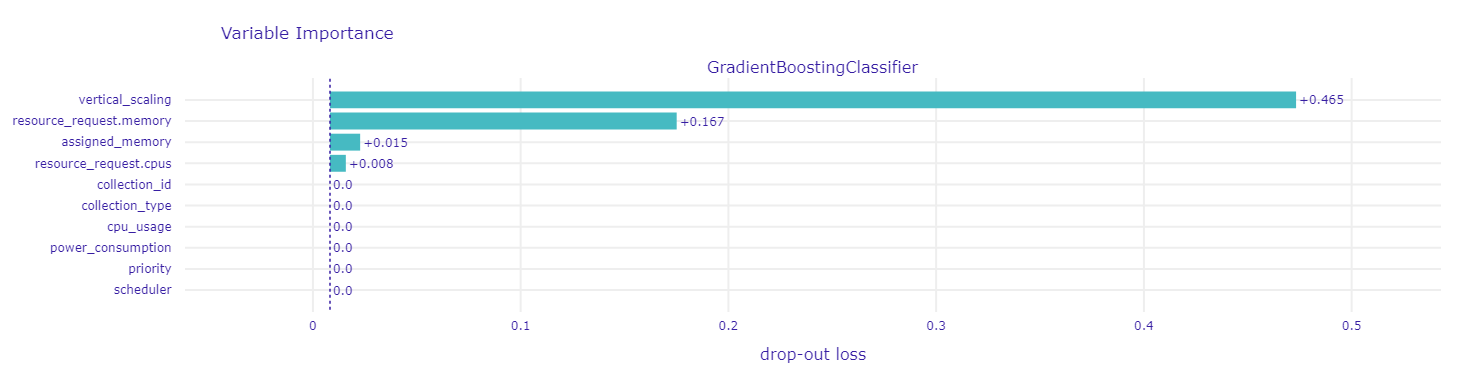

In [206]:
explanation_GB_ROS_test = exp_GB_ROS_test.model_parts()
explanation_GB_ROS_test.result
explanation_GB_ROS_test.plot()

In [207]:
exp_GB_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.549214,0.450786,0.450786,GradientBoostingClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.549214,0.450786,0.450786,GradientBoostingClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.450204,-0.450204,0.450204,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.549214,0.450786,0.450786,GradientBoostingClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.547882,0.452118,0.452118,GradientBoostingClassifier,500103


##### Extreme Gradient Boosting

In [208]:
XGB_ROS_train = joblib.load('Jobs/ROS/XGBClassifier.model')
exp_XGB_ROS_train = dx.Explainer(XGB_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.5, max = 0.646
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.646, mean = -7.61e-05, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [209]:
exp_XGB_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.999294,0.986863,0.99304,0.992996,0.997682


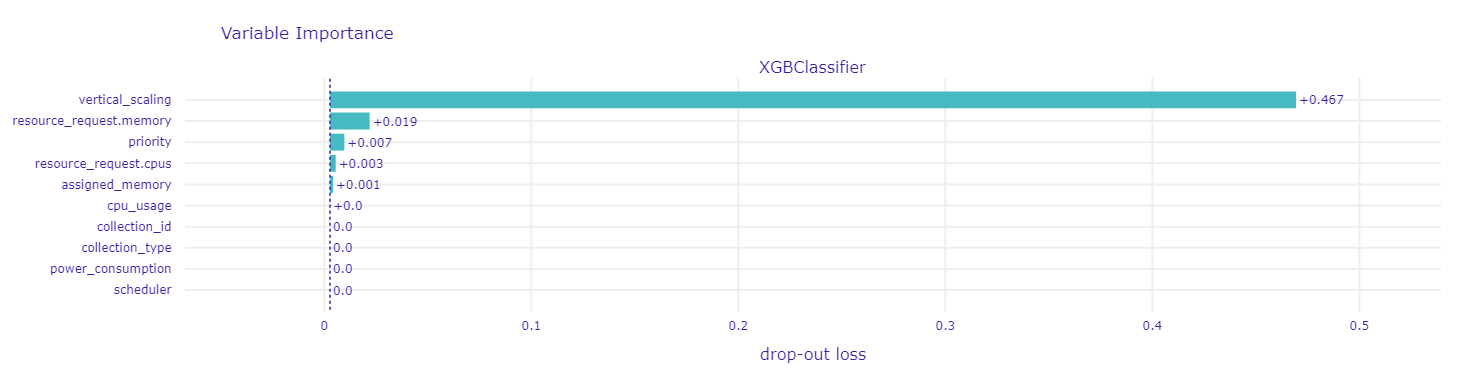

In [210]:
explanation_XGB_ROS_train = exp_XGB_ROS_train.model_parts()
explanation_XGB_ROS_train.result
explanation_XGB_ROS_train.plot()

In [211]:
exp_XGB_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.354381,-0.354381,0.354381,XGBClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.645507,0.354493,0.354493,XGBClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.354381,-0.354381,0.354381,XGBClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.354381,-0.354381,0.354381,XGBClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.354381,-0.354381,0.354381,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.645507,0.354493,0.354493,XGBClassifier,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.645507,0.354493,0.354493,XGBClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.645507,0.354493,0.354493,XGBClassifier,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.645507,0.354493,0.354493,XGBClassifier,1166723


In [212]:
XGB_ROS_test = joblib.load('Jobs/ROS/XGBClassifier.model')
exp_XGB_ROS_test = dx.Explainer(XGB_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.5, max = 0.646
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.646, mean = -6.69e-05, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [213]:
exp_XGB_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.99936,0.986935,0.993109,0.993065,0.997624


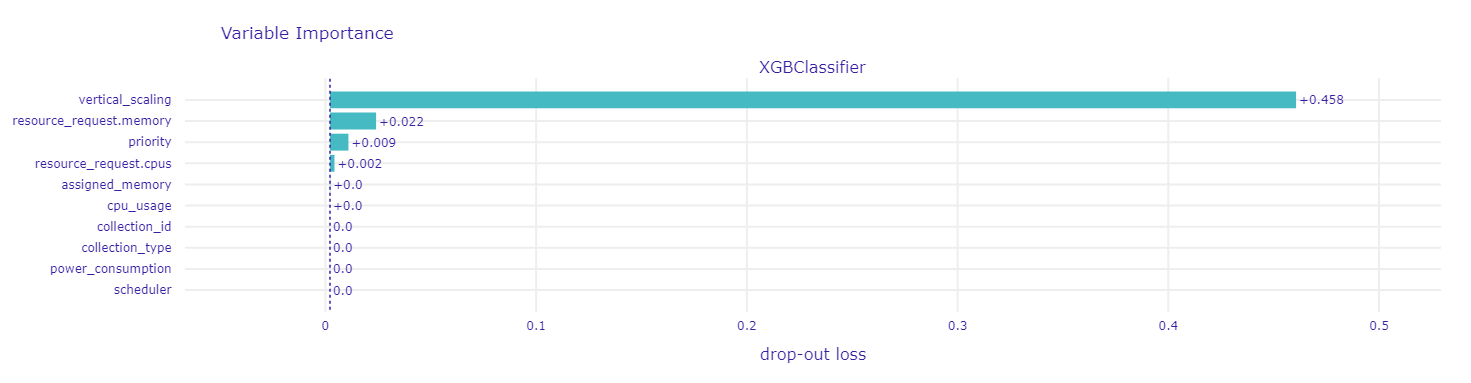

In [214]:
explanation_XGB_ROS_test = exp_XGB_ROS_test.model_parts()
explanation_XGB_ROS_test.result
explanation_XGB_ROS_test.plot()

In [215]:
exp_XGB_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.645652,0.354348,0.354348,XGBClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.645652,0.354348,0.354348,XGBClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.354381,-0.354381,0.354381,XGBClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.354381,-0.354381,0.354381,XGBClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.354381,-0.354381,0.354381,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.637646,0.362354,0.362354,XGBClassifier,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.645652,0.354348,0.354348,XGBClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.645507,0.354493,0.354493,XGBClassifier,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.637646,0.362354,0.362354,XGBClassifier,500103


#### With Imbalanced Handling - Using SMOTE

##### Logistic Regression

In [216]:
LR_SMOTE_train = joblib.load('Jobs/SMOTE/LogReg.model')
exp_LR_SMOTE_train = dx.Explainer(LR_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 9.46e-06, mean = 0.5, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -9.71e-05, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [217]:
exp_LR_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.802755,0.837594,0.819805,0.823552,0.912531


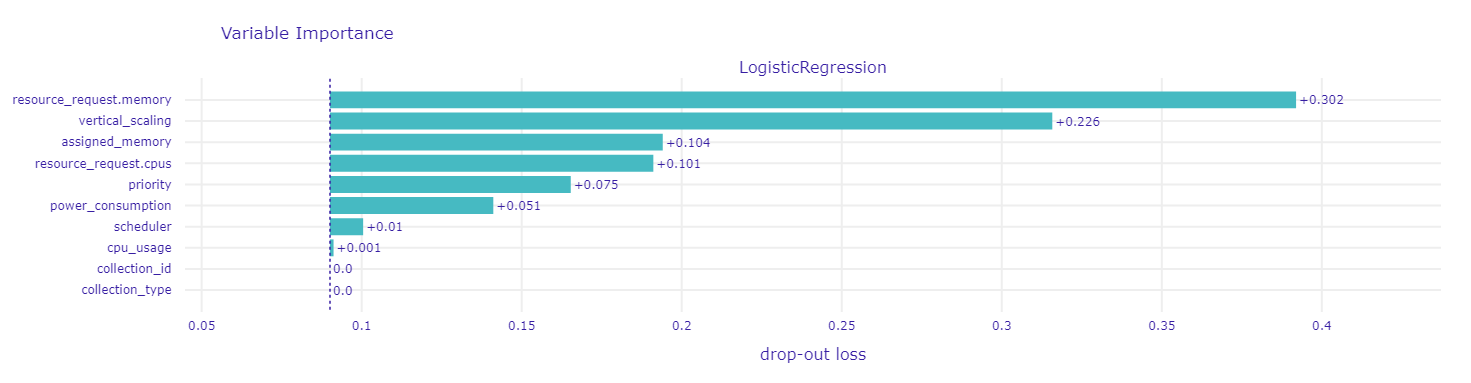

In [218]:
explanation_LR_SMOTE_train = exp_LR_SMOTE_train.model_parts()
explanation_LR_SMOTE_train.result
explanation_LR_SMOTE_train.plot()

In [219]:
exp_LR_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.013615,-0.013615,0.013615,LogisticRegression,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.945599,0.054401,0.054401,LogisticRegression,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.128128,-0.128128,0.128128,LogisticRegression,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.128143,-0.128143,0.128143,LogisticRegression,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.604472,-0.604472,0.604472,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.235156,0.764844,0.764844,LogisticRegression,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.235095,0.764905,0.764905,LogisticRegression,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.948940,0.051060,0.051060,LogisticRegression,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.938535,0.061465,0.061465,LogisticRegression,1166723


In [220]:
LR_SMOTE_test = joblib.load('Jobs/SMOTE/LogReg.model')
exp_LR_SMOTE_test = dx.Explainer(LR_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 2.73e-05, mean = 0.499, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = 0.000517, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [221]:
exp_LR_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
LogisticRegression,0.801205,0.837313,0.818861,0.822767,0.912032


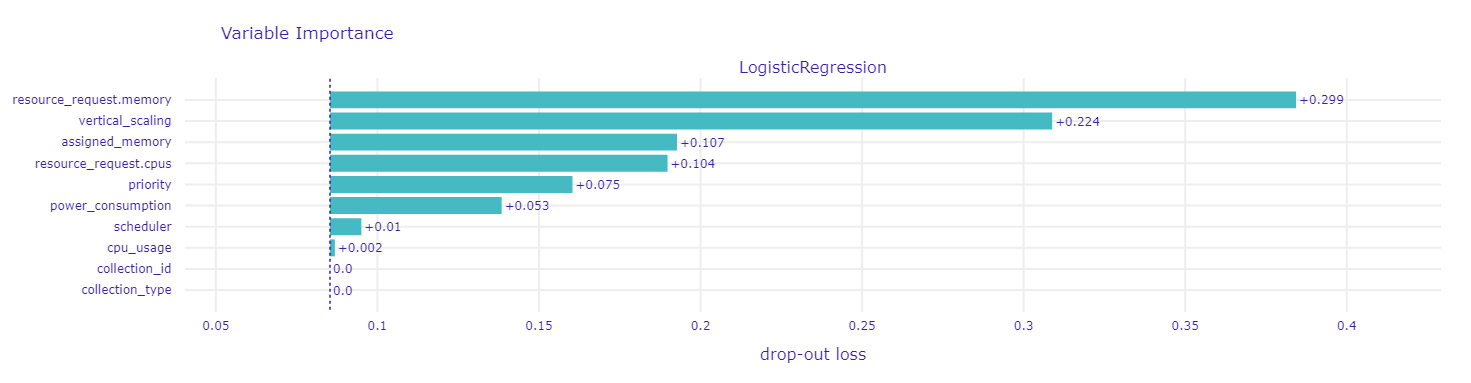

In [222]:
explanation_LR_SMOTE_test = exp_LR_SMOTE_test.model_parts()
explanation_LR_SMOTE_test.result
explanation_LR_SMOTE_test.plot()

In [223]:
exp_LR_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.236080,0.763920,0.763920,LogisticRegression,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.197364,0.802636,0.802636,LogisticRegression,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.128134,-0.128134,0.128134,LogisticRegression,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.016555,-0.016555,0.016555,LogisticRegression,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.683163,-0.683163,0.683163,LogisticRegression,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.946443,0.053557,0.053557,LogisticRegression,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.995732,0.004268,0.004268,LogisticRegression,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.946564,0.053436,0.053436,LogisticRegression,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.948870,0.051130,0.051130,LogisticRegression,500103


##### Decision Tree

In [224]:
DT_SMOTE_train = joblib.load('Jobs/SMOTE/DecisionTreeClassifier.model')
exp_DT_SMOTE_train = dx.Explainer(DT_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.17, mean = 0.5, max = 0.969
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = -0.0003, max = 0.83
  -> model_info        : package sklearn

A new explainer has been created!


In [225]:
exp_DT_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.800731,0.969319,0.876997,0.887693,0.887693


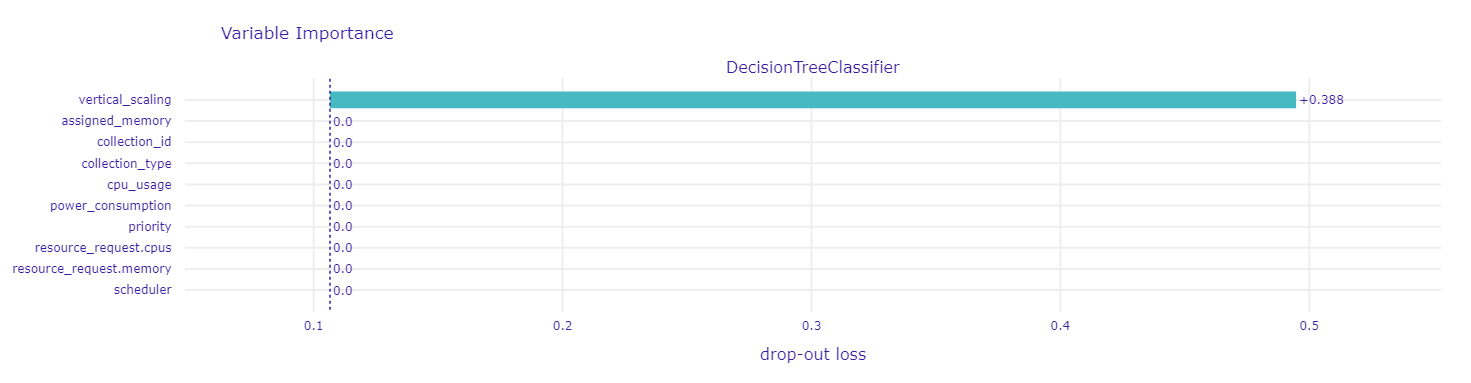

In [226]:
explanation_DT_SMOTE_train = exp_DT_SMOTE_train.model_parts()
explanation_DT_SMOTE_train.result
explanation_DT_SMOTE_train.plot()

In [227]:
exp_DT_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.170375,0.829625,0.829625,DecisionTreeClassifier,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.170375,0.829625,0.829625,DecisionTreeClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,1166723


In [228]:
DT_SMOTE_test = joblib.load('Jobs/SMOTE/DecisionTreeClassifier.model')
exp_DT_SMOTE_test = dx.Explainer(DT_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.17, mean = 0.499, max = 0.969
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = 0.00142, max = 0.83
  -> model_info        : package sklearn

A new explainer has been created!


In [229]:
exp_DT_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
DecisionTreeClassifier,0.79673,0.969516,0.874672,0.88584,0.88584


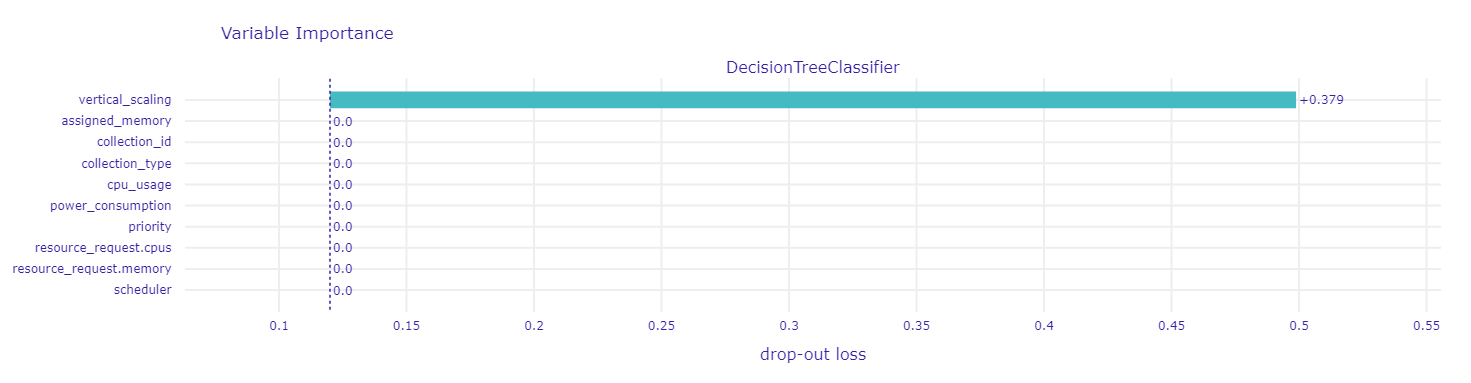

In [230]:
explanation_DT_SMOTE_test = exp_DT_SMOTE_test.model_parts()
explanation_DT_SMOTE_test.result
explanation_DT_SMOTE_test.plot()

In [231]:
exp_DT_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.170375,0.829625,0.829625,DecisionTreeClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.170375,0.829625,0.829625,DecisionTreeClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.170375,-0.170375,0.170375,DecisionTreeClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.969150,0.030850,0.030850,DecisionTreeClassifier,500103


##### Random Forest

In [232]:
RF_SMOTE_train = joblib.load('Jobs/SMOTE/RandomForestClassifier.model')
exp_RF_SMOTE_train = dx.Explainer(RF_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.237, mean = 0.5, max = 0.893
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.893, mean = -0.00022, max = 0.76
  -> model_info        : package sklearn

A new explainer has been created!


In [233]:
exp_RF_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.81596,0.952785,0.87908,0.887763,0.899554


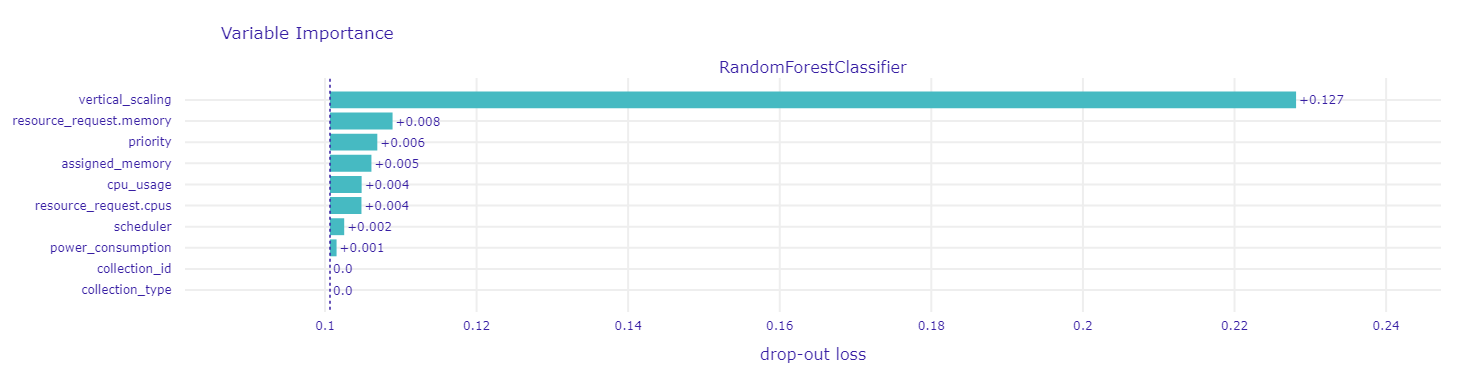

In [234]:
explanation_RF_SMOTE_train = exp_RF_SMOTE_train.model_parts()
explanation_RF_SMOTE_train.result
explanation_RF_SMOTE_train.plot()

In [235]:
exp_RF_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.263425,-0.263425,0.263425,RandomForestClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.892776,0.107224,0.107224,RandomForestClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.239834,-0.239834,0.239834,RandomForestClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.239834,-0.239834,0.239834,RandomForestClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.263425,-0.263425,0.263425,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.239834,0.760166,0.760166,RandomForestClassifier,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.239834,0.760166,0.760166,RandomForestClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.892776,0.107224,0.107224,RandomForestClassifier,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.803908,0.196092,0.196092,RandomForestClassifier,1166723


In [236]:
RF_SMOTE_test = joblib.load('Jobs/SMOTE/RandomForestClassifier.model')
exp_RF_SMOTE_test = dx.Explainer(RF_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.237, mean = 0.499, max = 0.893
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.893, mean = 0.000811, max = 0.76
  -> model_info        : package sklearn

A new explainer has been created!


In [237]:
exp_RF_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
RandomForestClassifier,0.812171,0.953218,0.87706,0.886156,0.898465


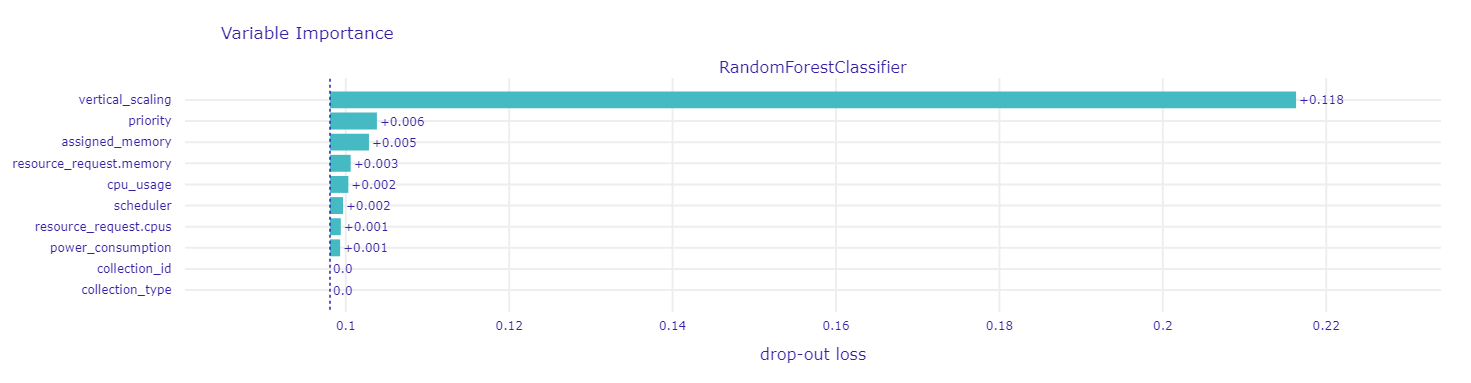

In [238]:
explanation_RF_SMOTE_test = exp_RF_SMOTE_test.model_parts()
explanation_RF_SMOTE_test.result
explanation_RF_SMOTE_test.plot()

In [239]:
exp_RF_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.239834,0.760166,0.760166,RandomForestClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.263425,0.736575,0.736575,RandomForestClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.239834,-0.239834,0.239834,RandomForestClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.263425,-0.263425,0.263425,RandomForestClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.239834,-0.239834,0.239834,RandomForestClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.892776,0.107224,0.107224,RandomForestClassifier,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.699127,0.300873,0.300873,RandomForestClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.892776,0.107224,0.107224,RandomForestClassifier,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.892776,0.107224,0.107224,RandomForestClassifier,500103


##### Gradient Boosting

In [240]:
GB_SMOTE_train = joblib.load('Jobs/SMOTE/GradientBoostingClassifier.model')
exp_GB_SMOTE_train = dx.Explainer(GB_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.45, mean = 0.5, max = 0.55
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.549, mean = -2.11e-06, max = 0.55
  -> model_info        : package sklearn

A new explainer has been created!


In [241]:
exp_GB_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.999439,0.980072,0.989661,0.989559,0.992306


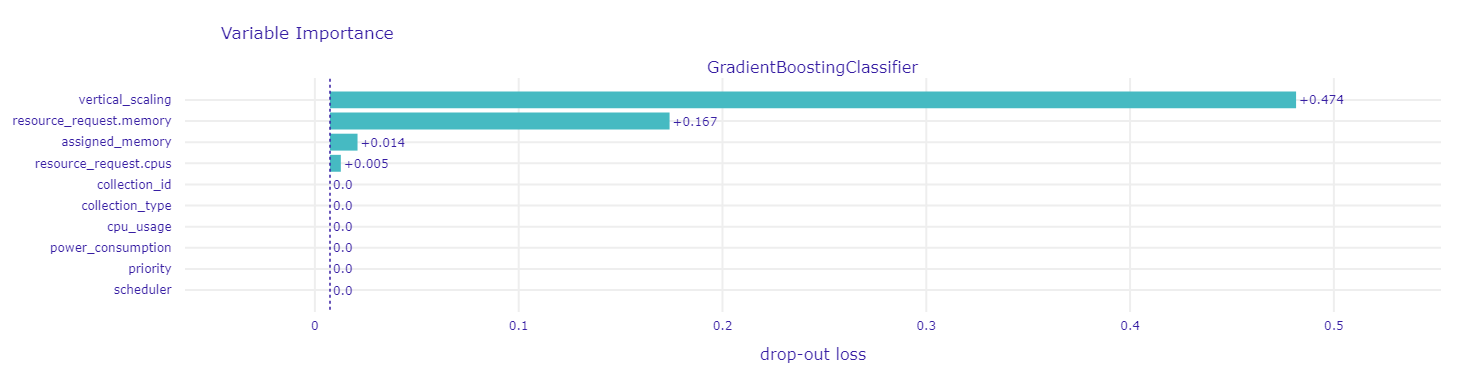

In [242]:
explanation_GB_SMOTE_train = exp_GB_SMOTE_train.model_parts()
explanation_GB_SMOTE_train.result
explanation_GB_SMOTE_train.plot()

In [243]:
exp_GB_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.549216,0.450784,0.450784,GradientBoostingClassifier,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.549216,0.450784,0.450784,GradientBoostingClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,1166723


In [244]:
GB_SMOTE_test = joblib.load('Jobs/SMOTE/GradientBoostingClassifier.model')
exp_GB_SMOTE_test = dx.Explainer(GB_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.45, mean = 0.5, max = 0.55
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.549, mean = 3.34e-06, max = 0.55
  -> model_info        : package sklearn

A new explainer has been created!


In [245]:
exp_GB_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
GradientBoostingClassifier,0.999332,0.980318,0.989734,0.989634,0.992405


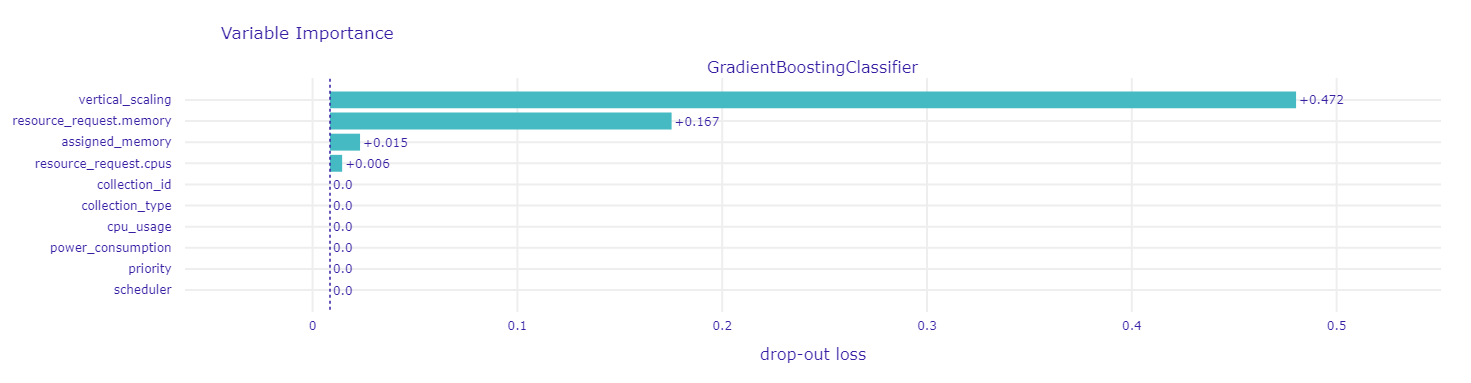

In [246]:
explanation_GB_SMOTE_test = exp_GB_SMOTE_test.model_parts()
explanation_GB_SMOTE_test.result
explanation_GB_SMOTE_test.plot()

In [247]:
exp_GB_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.549216,0.450784,0.450784,GradientBoostingClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.549216,0.450784,0.450784,GradientBoostingClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.450208,-0.450208,0.450208,GradientBoostingClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.547880,0.452120,0.452120,GradientBoostingClassifier,500103


##### Extreme Gradient Boosting

In [248]:
XGB_SMOTE_train = joblib.load('Jobs/SMOTE/XGBClassifier.model')
exp_XGB_SMOTE_train = dx.Explainer(XGB_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.5, max = 0.646
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.646, mean = -6.73e-05, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [249]:
exp_XGB_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.999261,0.986863,0.993023,0.992979,0.997665


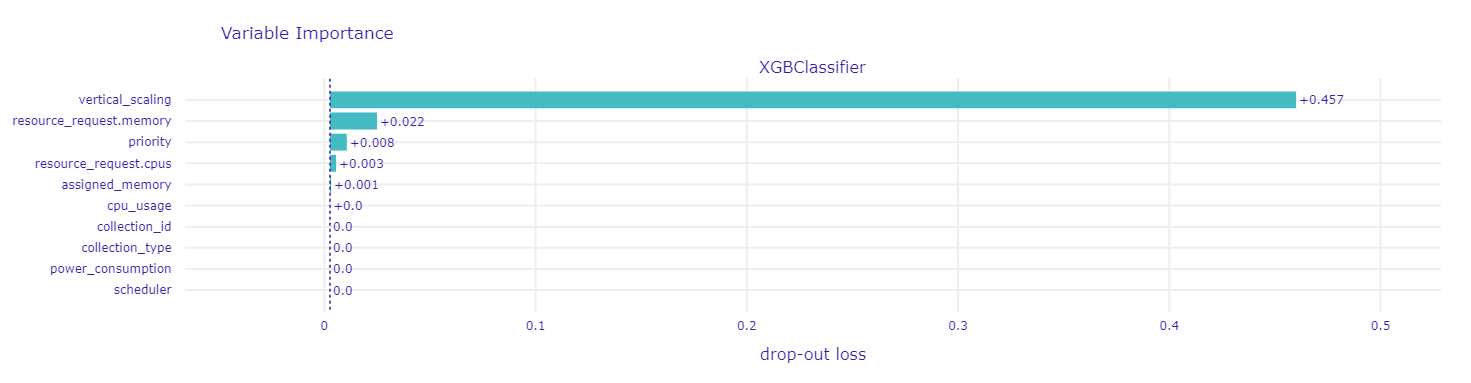

In [250]:
explanation_XGB_SMOTE_train = exp_XGB_SMOTE_train.model_parts()
explanation_XGB_SMOTE_train.result
explanation_XGB_SMOTE_train.plot()

In [251]:
exp_XGB_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.354373,-0.354373,0.354373,XGBClassifier,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.645507,0.354493,0.354493,XGBClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.354373,-0.354373,0.354373,XGBClassifier,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.354373,-0.354373,0.354373,XGBClassifier,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.354373,-0.354373,0.354373,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.645652,0.354348,0.354348,XGBClassifier,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.645652,0.354348,0.354348,XGBClassifier,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.645507,0.354493,0.354493,XGBClassifier,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.637624,0.362376,0.362376,XGBClassifier,1166723


In [252]:
XGB_SMOTE_test = joblib.load('Jobs/SMOTE/XGBClassifier.model')
exp_XGB_SMOTE_test = dx.Explainer(XGB_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x000002D212BDC4C0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.354, mean = 0.5, max = 0.646
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.646, mean = -5.2e-05, max = 0.646
  -> model_info        : package sklearn

A new explainer has been created!


In [253]:
exp_XGB_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
XGBClassifier,0.999344,0.986935,0.993101,0.993057,0.997606


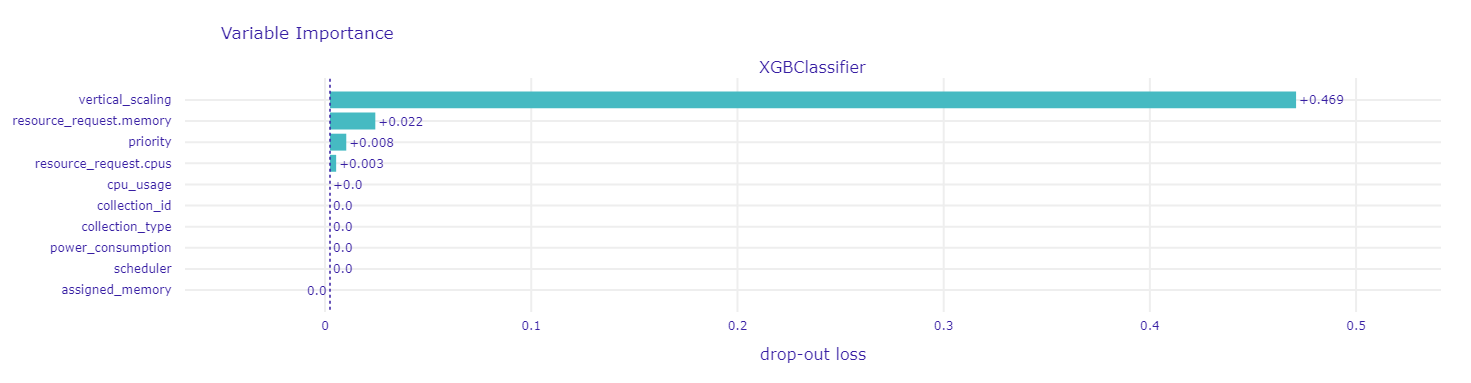

In [254]:
explanation_XGB_SMOTE_test = exp_XGB_SMOTE_test.model_parts()
explanation_XGB_SMOTE_test.result
explanation_XGB_SMOTE_test.plot()

In [255]:
exp_XGB_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.645652,0.354348,0.354348,XGBClassifier,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.645652,0.354348,0.354348,XGBClassifier,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.354373,-0.354373,0.354373,XGBClassifier,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.354373,-0.354373,0.354373,XGBClassifier,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.354373,-0.354373,0.354373,XGBClassifier,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.645507,0.354493,0.354493,XGBClassifier,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.645507,0.354493,0.354493,XGBClassifier,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.645507,0.354493,0.354493,XGBClassifier,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.645507,0.354493,0.354493,XGBClassifier,500103


##### LSTM Without Imbalanced Handling

In [29]:
LSTM_train = km.load_model('Jobs/LSTM/LSTM_Without.keras')
exp_LSTM_train = dx.Explainer(LSTM_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 3.44e-05, mean = 0.171, max = 0.994
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.992, mean = -0.00388, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [30]:
exp_LSTM_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.991915,0.928636,0.959233,0.985951,0.997305


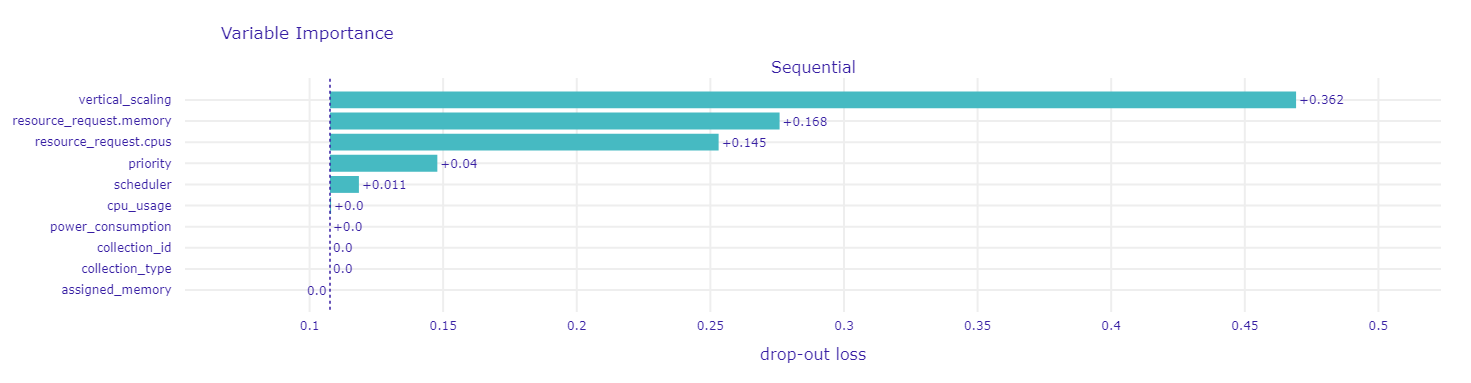

In [31]:
explanation_LSTM_train = exp_LSTM_train.model_parts()
explanation_LSTM_train.result
explanation_LSTM_train.plot()

In [32]:
exp_LSTM_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.000042,-0.000042,0.000042,Sequential,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.987222,0.012778,0.012778,Sequential,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.000039,-0.000039,0.000039,Sequential,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.000039,-0.000039,0.000039,Sequential,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.000043,-0.000043,0.000043,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.000044,-0.000044,0.000044,Sequential,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.000052,-0.000052,0.000052,Sequential,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.953413,0.046587,0.046587,Sequential,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.000039,-0.000039,0.000039,Sequential,699999


In [33]:
LSTM_test = km.load_model('Jobs/LSTM/LSTM_Without.keras')
exp_LSTM_test = dx.Explainer(LSTM_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 3.44e-05, mean = 0.17, max = 0.994
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.992, mean = -0.00382, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [34]:
exp_LSTM_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.991932,0.928766,0.95931,0.98599,0.997187


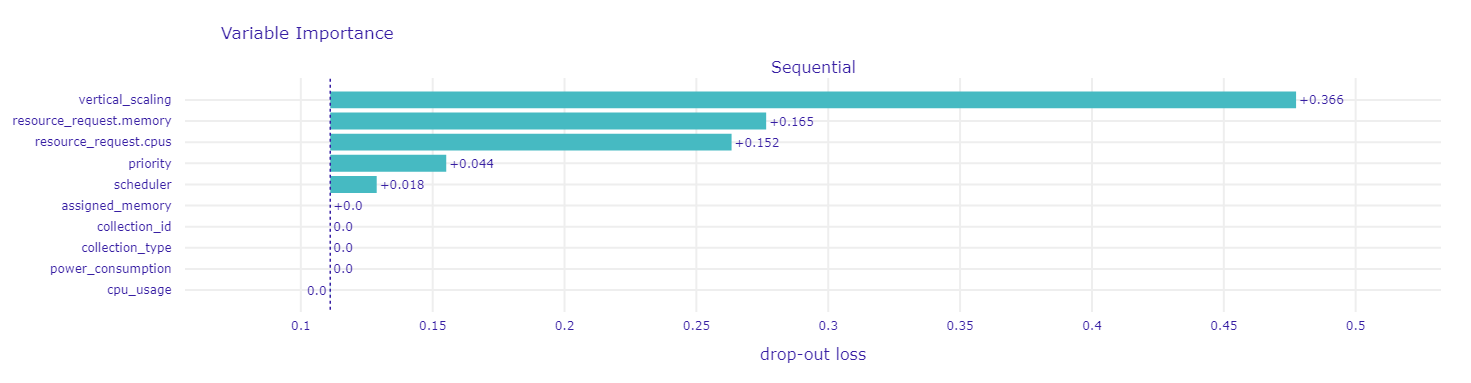

In [35]:
explanation_LSTM_test = exp_LSTM_test.model_parts()
explanation_LSTM_test.result
explanation_LSTM_test.plot()

In [36]:
exp_LSTM_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.991196,0.008804,0.008804,Sequential,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.991195,0.008805,0.008805,Sequential,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.000039,-0.000039,0.000039,Sequential,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.000042,-0.000042,0.000042,Sequential,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.000291,-0.000291,0.000291,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.000043,-0.000043,0.000043,Sequential,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.000039,-0.000039,0.000039,Sequential,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.000044,-0.000044,0.000044,Sequential,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.000044,-0.000044,0.000044,Sequential,299999


##### LSTM With RUS

In [37]:
LSTM_RUS = km.load_model('Jobs/LSTM/LSTM_RUS.keras')
exp_LSTM_RUS = dx.Explainer(LSTM_RUS, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000986, mean = 0.502, max = 0.996
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.996, mean = -0.00163, max = 0.999
  -> model_info        : package keras

A new explainer has been created!


In [38]:
exp_LSTM_RUS.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999151,0.979756,0.989358,0.989253,0.98958


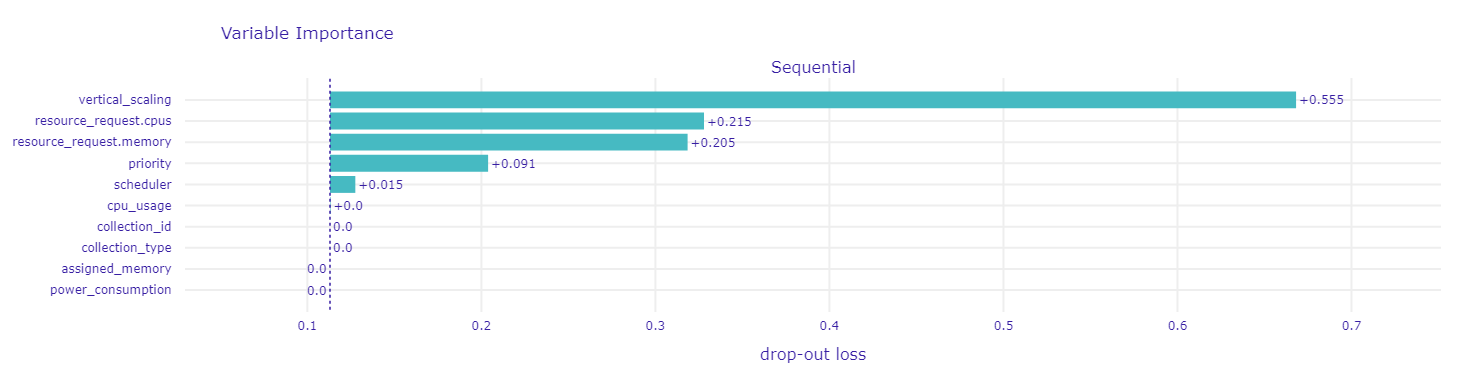

In [39]:
explanation_LSTM_RUS_train = exp_LSTM_RUS.model_parts()
explanation_LSTM_RUS_train.result
explanation_LSTM_RUS_train.plot()

In [40]:
exp_LSTM_RUS.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.001760,-0.001760,0.001760,Sequential,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.001760,-0.001760,0.001760,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.001760,-0.001760,0.001760,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.001760,-0.001760,0.001760,Sequential,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.001760,-0.001760,0.001760,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.994865,0.005135,0.005135,Sequential,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.995318,0.004682,0.004682,Sequential,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.994124,0.005876,0.005876,Sequential,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.995723,0.004277,0.004277,Sequential,233275


In [41]:
LSTM_RUS_test = km.load_model('Jobs/LSTM/LSTM_RUS.keras')
exp_LSTM_RUS_test = dx.Explainer(LSTM_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000986, mean = 0.502, max = 0.996
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.996, mean = -0.00201, max = 0.999
  -> model_info        : package keras

A new explainer has been created!


In [42]:
exp_LSTM_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999059,0.978317,0.988579,0.988458,0.98897


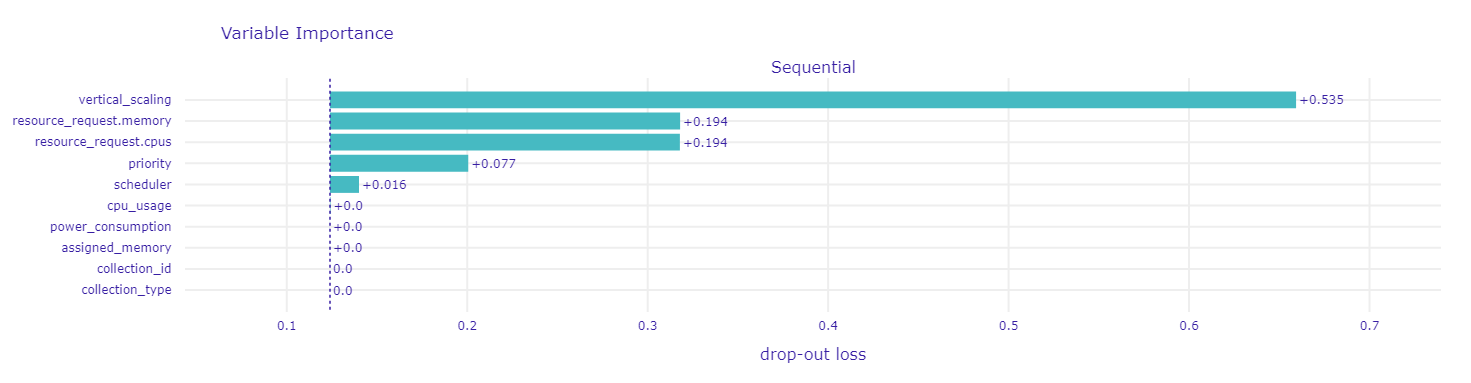

In [43]:
explanation_LSTM_RUS_test = exp_LSTM_RUS_test.model_parts()
explanation_LSTM_RUS_test.result
explanation_LSTM_RUS_test.plot()

In [44]:
exp_LSTM_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.001760,-0.001760,0.001760,Sequential,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.001760,-0.001760,0.001760,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.001760,-0.001760,0.001760,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.001760,-0.001760,0.001760,Sequential,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.002030,-0.002030,0.002030,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.994065,0.005935,0.005935,Sequential,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.994873,0.005127,0.005127,Sequential,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.994475,0.005525,0.005525,Sequential,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.995318,0.004682,0.004682,Sequential,99895


##### LSTM With ROS

In [45]:
LSTM_ROS_train = km.load_model('Jobs/LSTM/LSTM_ROS.keras')
exp_LSTM_ROS_train = dx.Explainer(LSTM_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 2.14e-06, mean = 0.507, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00701, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [46]:
exp_LSTM_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999664,0.98331,0.99142,0.991348,0.997307


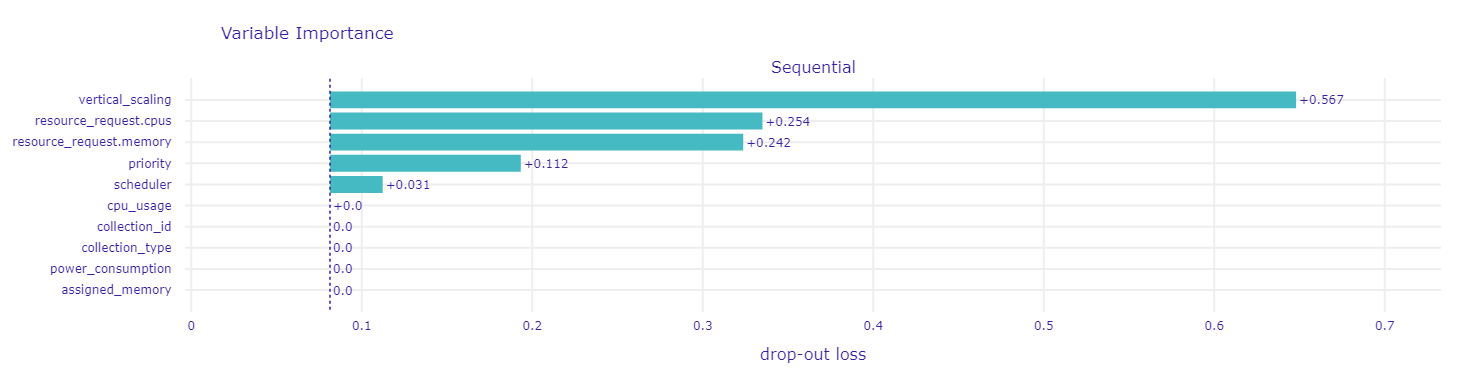

In [47]:
explanation_LSTM_ROS_train = exp_LSTM_ROS_train.model_parts()
explanation_LSTM_ROS_train.result
explanation_LSTM_ROS_train.plot()

In [48]:
exp_LSTM_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.000021,-0.000021,0.000021,Sequential,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.999468,0.000532,0.000532,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.000009,-0.000009,0.000009,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.000009,-0.000009,0.000009,Sequential,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.000009,-0.000009,0.000009,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.999468,0.000532,0.000532,Sequential,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.999468,0.000532,0.000532,Sequential,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.999468,0.000532,0.000532,Sequential,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.999468,0.000532,0.000532,Sequential,1166723


In [49]:
LSTM_ROS_test = km.load_model('Jobs/LSTM/LSTM_ROS.keras')
exp_LSTM_ROS_test = dx.Explainer(LSTM_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 2.14e-06, mean = 0.507, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00689, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [50]:
exp_LSTM_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.99946,0.983422,0.991376,0.991306,0.997188


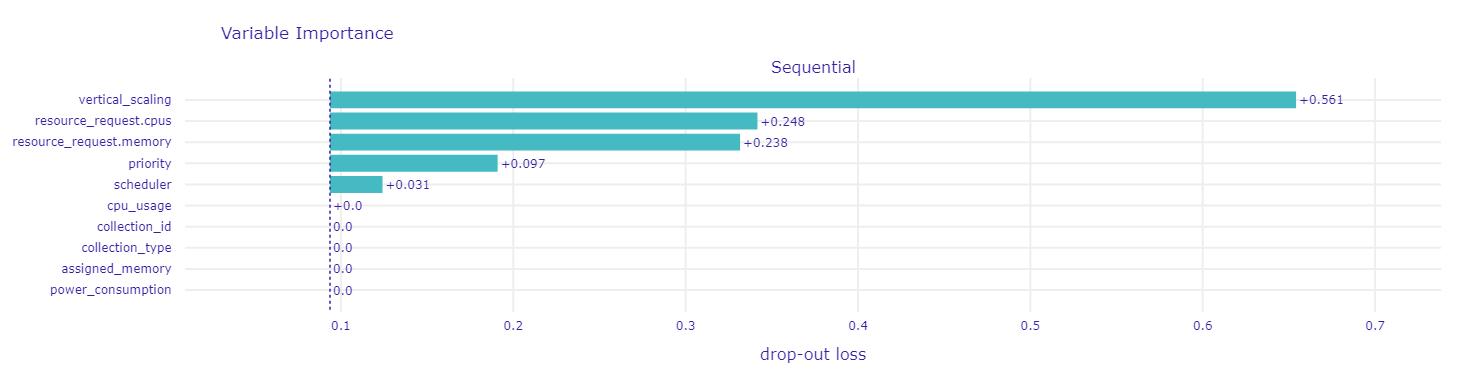

In [51]:
explanation_LSTM_ROS_test = exp_LSTM_ROS_test.model_parts()
explanation_LSTM_ROS_test.result
explanation_LSTM_ROS_test.plot()

In [52]:
exp_LSTM_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.999846,0.000154,0.000154,Sequential,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.999846,0.000154,0.000154,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.000009,-0.000009,0.000009,Sequential,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.000021,-0.000021,0.000021,Sequential,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.002467,-0.002467,0.002467,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.995253,0.004747,0.004747,Sequential,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.999846,0.000154,0.000154,Sequential,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.999468,0.000532,0.000532,Sequential,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.987593,0.012407,0.012407,Sequential,500103


##### LSTM With SMOTE

In [53]:
LSTM_SMOTE_train = km.load_model('Jobs/LSTM/LSTM_SMOTE.keras')
exp_LSTM_SMOTE_train = dx.Explainer(LSTM_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 1.95e-05, mean = 0.507, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00669, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [54]:
exp_LSTM_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999889,0.980969,0.990339,0.990245,0.994429


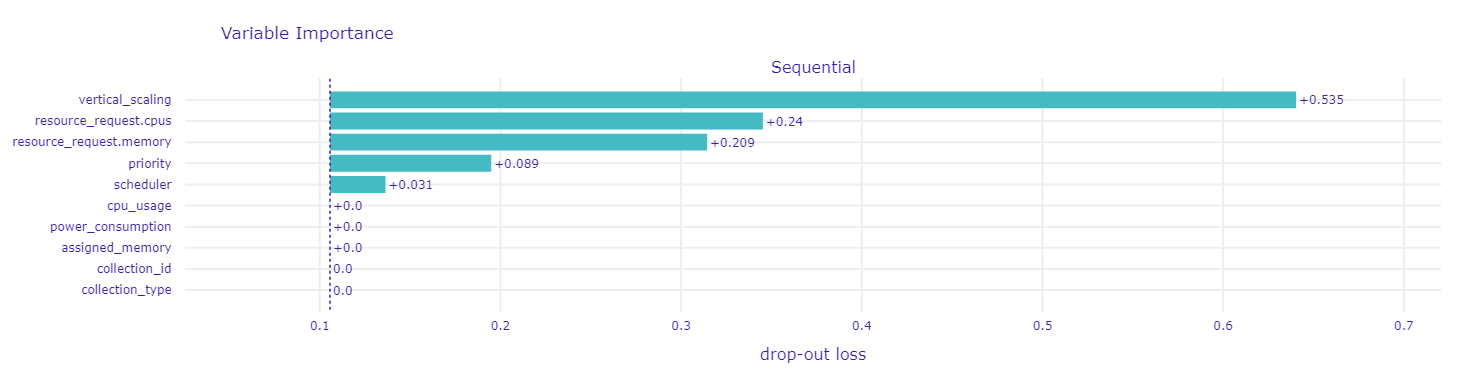

In [55]:
explanation_LSTM_SMOTE_train = exp_LSTM_SMOTE_train.model_parts()
explanation_LSTM_SMOTE_train.result
explanation_LSTM_SMOTE_train.plot()

In [56]:
exp_LSTM_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.000033,-0.000033,0.000033,Sequential,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.999003,0.000997,0.000997,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.000077,-0.000077,0.000077,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.000077,-0.000077,0.000077,Sequential,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.000030,-0.000030,0.000030,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.999495,0.000505,0.000505,Sequential,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.999495,0.000505,0.000505,Sequential,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.999003,0.000997,0.000997,Sequential,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.993415,0.006585,0.006585,Sequential,1166723


In [57]:
LSTM_SMOTE_test = km.load_model('Jobs/LSTM/LSTM_SMOTE.keras')
exp_LSTM_SMOTE_test = dx.Explainer(LSTM_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 2e-05, mean = 0.506, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.999, mean = -0.00647, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [58]:
exp_LSTM_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999752,0.981192,0.990385,0.990294,0.994421


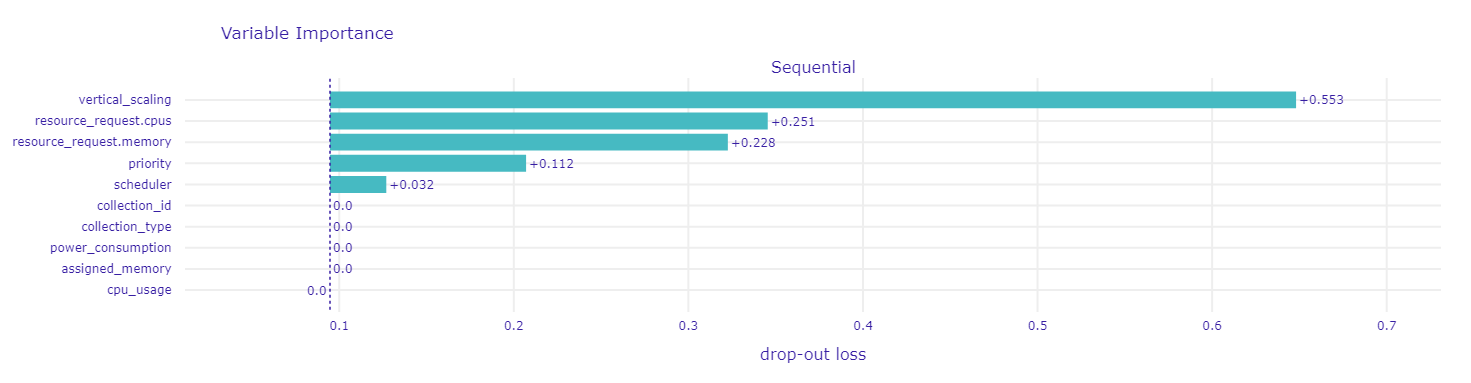

In [59]:
explanation_LSTM_SMOTE_test = exp_LSTM_SMOTE_test.model_parts()
explanation_LSTM_SMOTE_test.result
explanation_LSTM_SMOTE_test.plot()

In [60]:
exp_LSTM_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.999495,0.000505,0.000505,Sequential,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.999495,0.000505,0.000505,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.000077,-0.000077,0.000077,Sequential,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.000033,-0.000033,0.000033,Sequential,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.006740,-0.006740,0.006740,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.999003,0.000997,0.000997,Sequential,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.997935,0.002065,0.002065,Sequential,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.999003,0.000997,0.000997,Sequential,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.999003,0.000997,0.000997,Sequential,500103


##### GRU Without Imbalanced Handling

In [61]:
GRU_train = km.load_model('Jobs/GRU/GRU_Without.keras')
exp_GRU_train = dx.Explainer(GRU_train, X_train, Y_train)

Preparation of a new explainer is initiated

  -> data              : 700000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 700000 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 4.96e-05, mean = 0.173, max = 0.996
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.995, mean = -0.00664, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [62]:
exp_GRU_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.992781,0.922494,0.956348,0.984899,0.996335


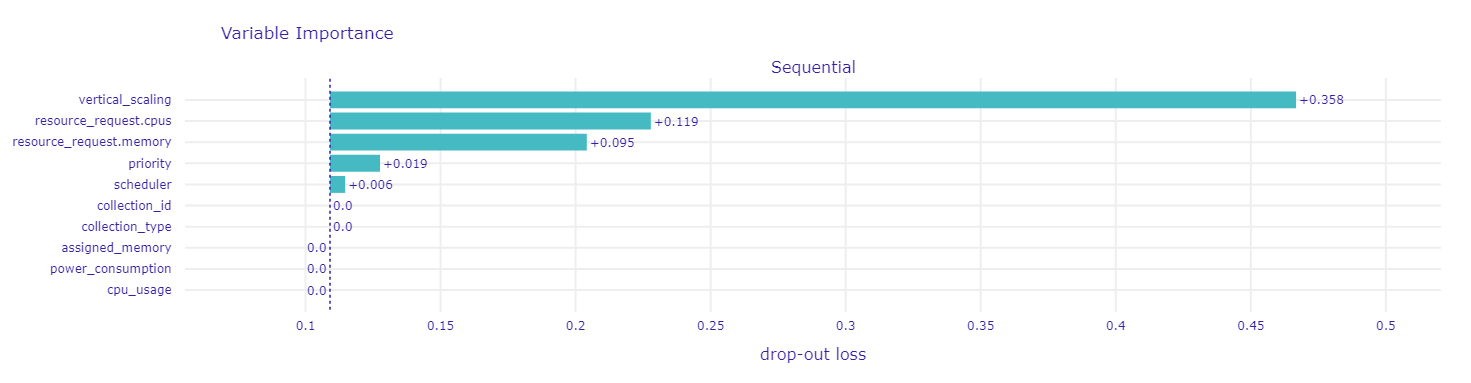

In [63]:
explanation_GRU_train = exp_GRU_train.model_parts()
explanation_GRU_train.result
explanation_GRU_train.plot()

In [64]:
exp_GRU_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
506532,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.000087,-0.000087,0.000087,Sequential,1
327991,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.993585,0.006415,0.006415,Sequential,2
715937,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.000054,-0.000054,0.000054,Sequential,3
860726,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.000054,-0.000054,0.000054,Sequential,4
78617,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.000056,-0.000056,0.000056,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,0.000044,87.005043,0.0,0.000057,-0.000057,0.000057,Sequential,699996
365838,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.002091,87.232322,0.0,0.000108,-0.000108,0.000108,Sequential,699997
131932,4.559057e+11,1.0,1.844303,1.784754,0.0,1.0,1.0,0.007812,0.024213,89.491665,1.0,0.978852,0.021148,0.021148,Sequential,699998
671155,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002031,87.225764,0.0,0.000054,-0.000054,0.000054,Sequential,699999


In [65]:
GRU_test = km.load_model('Jobs/GRU/GRU_Without.keras')
exp_GRU_test = dx.Explainer(GRU_test, X_test, Y_test)

Preparation of a new explainer is initiated

  -> data              : 300000 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 300000 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 4.96e-05, mean = 0.173, max = 0.996
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.995, mean = -0.00642, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [66]:
exp_GRU_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.992752,0.923114,0.956668,0.985027,0.996209


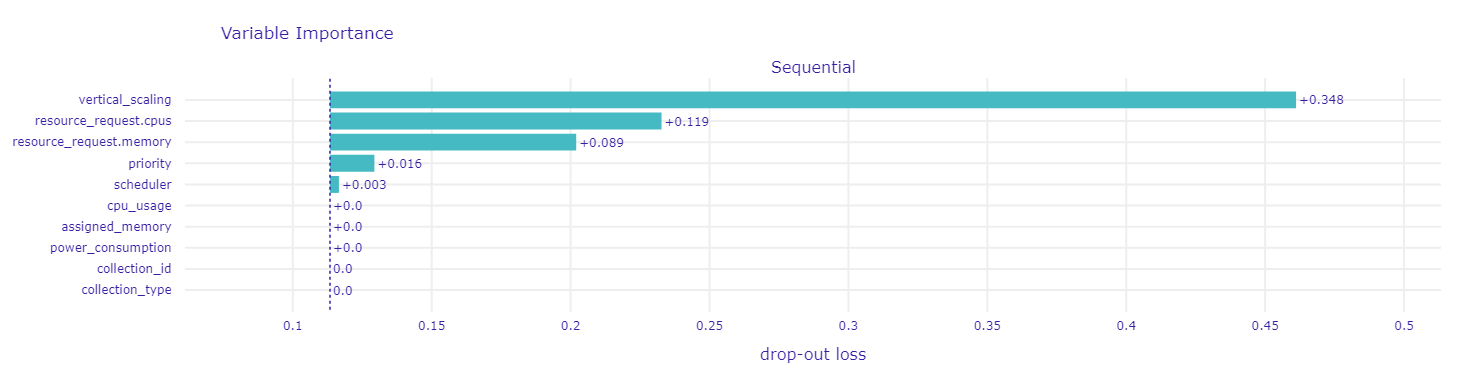

In [67]:
explanation_GRU_test = exp_GRU_test.model_parts()
explanation_GRU_test.result
explanation_GRU_test.plot()

In [68]:
exp_GRU_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
987231,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.993053,0.006947,0.006947,Sequential,1
79954,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.993049,0.006951,0.006951,Sequential,2
567130,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.000054,-0.000054,0.000054,Sequential,3
500891,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.000089,-0.000089,0.000089,Sequential,4
55399,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.003447,-0.003447,0.003447,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463299,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,2.015114e-03,87.223993,0.0,0.000094,-0.000094,0.000094,Sequential,299996
728324,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.230644e-03,87.247503,0.0,0.000054,-0.000054,0.000054,Sequential,299997
76260,4.622639e+11,1.0,-0.613973,0.950483,0.0,2.0,1.0,0.004112,8.382797e-04,87.094382,0.0,0.000057,-0.000057,0.000057,Sequential,299998
77813,4.605303e+11,1.0,-0.613973,0.947843,0.0,2.0,1.0,0.004112,8.192062e-04,87.092260,0.0,0.000057,-0.000057,0.000057,Sequential,299999


##### GRU With RUS

In [69]:
GRU_RUS_train = km.load_model('Jobs/GRU/GRU_RUS.keras')
exp_GRU_RUS_train = dx.Explainer(GRU_RUS_train, X_train_RUS, Y_train_RUS)

Preparation of a new explainer is initiated

  -> data              : 233276 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 233276 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000903, mean = 0.502, max = 0.998
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.998, mean = -0.00193, max = 0.999
  -> model_info        : package keras

A new explainer has been created!


In [70]:
exp_GRU_RUS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.998791,0.978563,0.988574,0.988456,0.99165


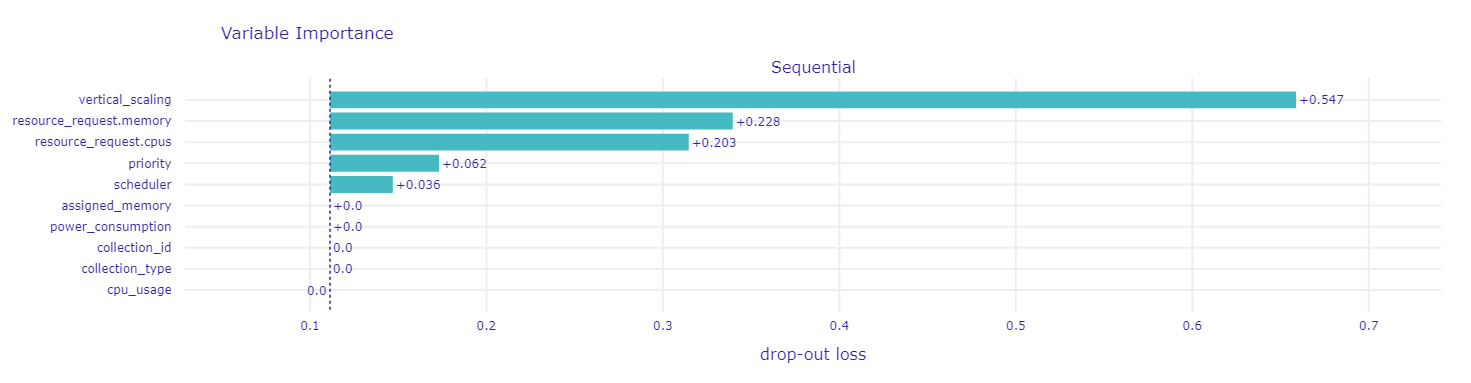

In [71]:
explanation_GRU_RUS_train = exp_GRU_RUS_train.model_parts()
explanation_GRU_RUS_train.result
explanation_GRU_RUS_train.plot()

In [72]:
exp_GRU_RUS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002285,87.253423,0.0,0.001191,-0.001191,0.001191,Sequential,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001895,87.210859,0.0,0.001191,-0.001191,0.001191,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002245,87.249061,0.0,0.001191,-0.001191,0.001191,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002182,87.242203,0.0,0.001191,-0.001191,0.001191,Sequential,4
4,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002246,87.249165,0.0,0.001191,-0.001191,0.001191,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233271,4.653859e+11,1.0,-0.672785,0.079991,0.0,3.0,1.0,0.002167,0.003828,87.420088,1.0,0.986539,0.013461,0.013461,Sequential,233272
233272,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.000023,87.002637,1.0,0.995419,0.004581,0.004581,Sequential,233273
233273,4.624253e+11,1.0,-0.672785,0.174650,0.0,3.0,1.0,0.002144,0.000040,87.004606,1.0,0.982202,0.017798,0.017798,Sequential,233274
233274,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.001297,0.003181,87.350552,1.0,0.995123,0.004877,0.004877,Sequential,233275


In [73]:
GRU_RUS_test = km.load_model('Jobs/GRU/GRU_RUS.keras')
exp_GRU_RUS_test = dx.Explainer(GRU_RUS_test, X_test_RUS, Y_test_RUS)

Preparation of a new explainer is initiated

  -> data              : 99896 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 99896 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000903, mean = 0.502, max = 0.998
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.998, mean = -0.00233, max = 0.999
  -> model_info        : package keras

A new explainer has been created!


In [74]:
exp_GRU_RUS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.998879,0.977221,0.987931,0.987797,0.991018


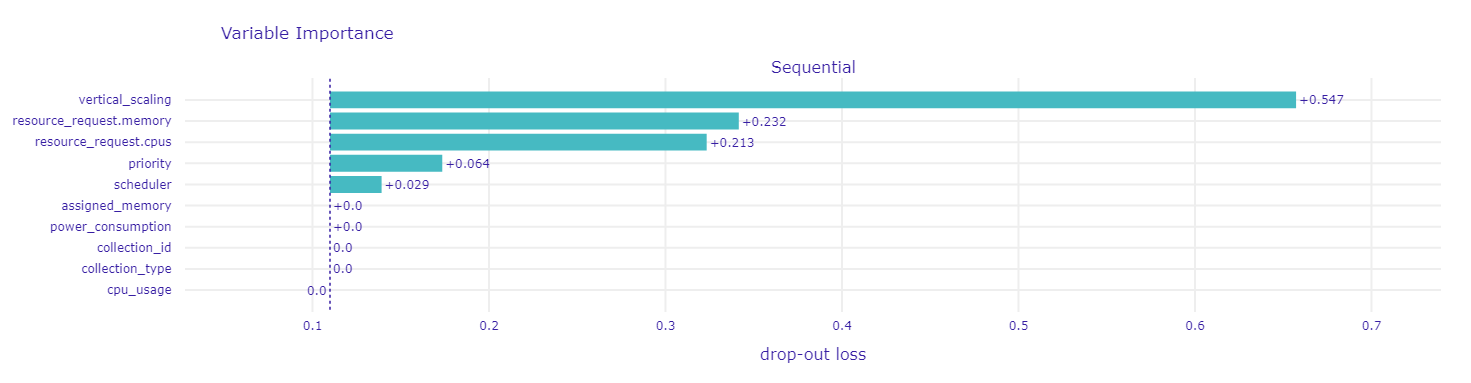

In [75]:
explanation_GRU_RUS_test = exp_GRU_RUS_test.model_parts()
explanation_GRU_RUS_test.result
explanation_GRU_RUS_test.plot()

In [76]:
exp_GRU_RUS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001969,87.218992,0.0,0.001191,-0.001191,0.001191,Sequential,1
1,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002211,87.245321,0.0,0.001191,-0.001191,0.001191,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002011,87.223577,0.0,0.001191,-0.001191,0.001191,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.001897,87.211068,0.0,0.001191,-0.001191,0.001191,Sequential,4
4,5.031836e+11,1.0,-0.613973,-0.389695,0.0,2.0,1.0,0.001410,0.001515,87.169236,0.0,0.002128,-0.002128,0.002128,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99891,4.985146e+11,1.0,-0.519638,0.245514,0.0,3.0,1.0,0.002472,0.002688,87.297243,1.0,0.968413,0.031587,0.031587,Sequential,99892
99892,4.938921e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.000000,87.000000,1.0,0.997256,0.002744,0.002744,Sequential,99893
99893,4.962994e+11,1.0,-0.463985,0.207339,0.0,3.0,1.0,0.002399,0.002175,87.241475,1.0,0.967573,0.032427,0.032427,Sequential,99894
99894,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003661,87.402178,1.0,0.995424,0.004576,0.004576,Sequential,99895


##### GRU With ROS

In [77]:
GRU_ROS_train = km.load_model('Jobs/GRU/GRU_ROS.keras')
exp_GRU_ROS_train = dx.Explainer(GRU_ROS_train, X_train_ROS, Y_train_ROS)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000104, mean = 0.506, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00582, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [78]:
exp_GRU_ROS_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999796,0.984752,0.992217,0.992158,0.99747


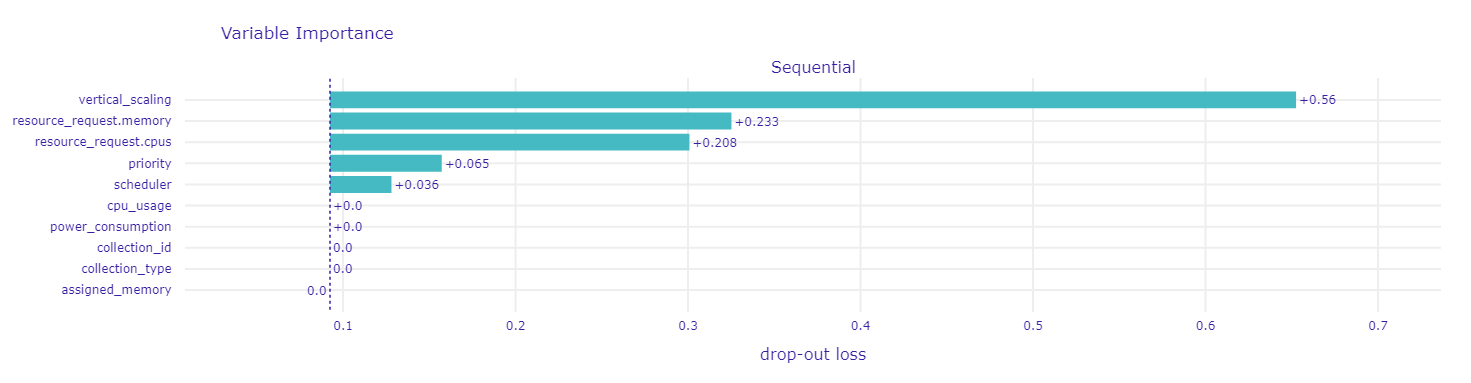

In [79]:
explanation_GRU_ROS_train = exp_GRU_ROS_train.model_parts()
explanation_GRU_ROS_train.result
explanation_GRU_ROS_train.plot()

In [80]:
exp_GRU_ROS_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.000119,-0.000119,0.000119,Sequential,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.999876,0.000124,0.000124,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.000108,-0.000108,0.000108,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.000108,-0.000108,0.000108,Sequential,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.000128,-0.000128,0.000128,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003940,87.432047,1.0,0.999876,0.000124,0.000124,Sequential,1166720
1166720,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003965,87.434806,1.0,0.999876,0.000124,0.000124,Sequential,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004735,87.516984,1.0,0.999876,0.000124,0.000124,Sequential,1166722
1166722,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004740,87.517491,1.0,0.999876,0.000124,0.000124,Sequential,1166723


In [81]:
GRU_ROS_test = km.load_model('Jobs/GRU/GRU_ROS.keras')
exp_GRU_ROS_test = dx.Explainer(GRU_ROS_test, X_test_ROS, Y_test_ROS)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000104, mean = 0.506, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00563, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [82]:
exp_GRU_ROS_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.99962,0.984928,0.99222,0.992162,0.997467


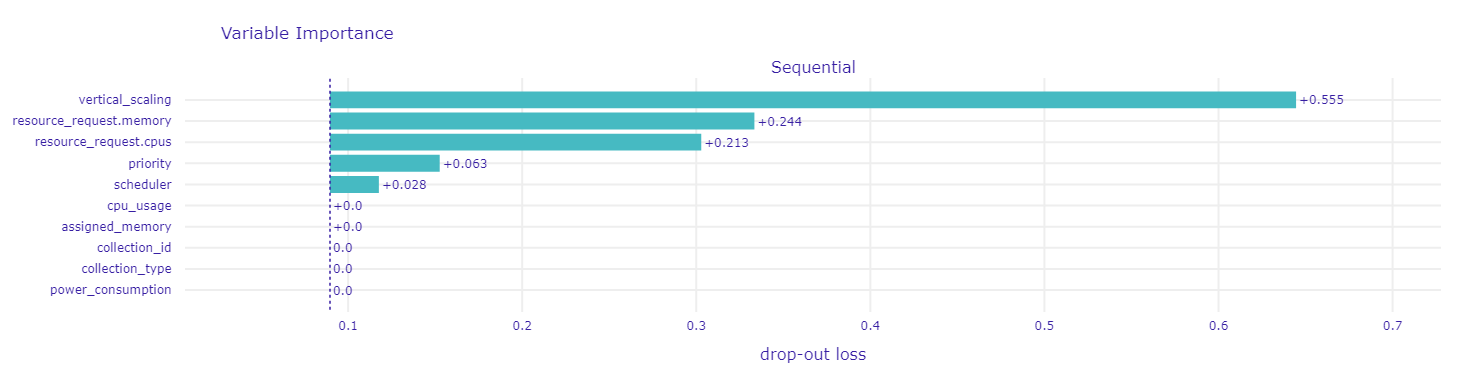

In [83]:
explanation_GRU_ROS_test = exp_GRU_ROS_test.model_parts()
explanation_GRU_ROS_test.result
explanation_GRU_ROS_test.plot()

In [84]:
exp_GRU_ROS_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.999874,0.000126,0.000126,Sequential,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.999874,0.000126,0.000126,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.000108,-0.000108,0.000108,Sequential,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.000119,-0.000119,0.000119,Sequential,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.000665,-0.000665,0.000665,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.975646e+11,1.0,-0.501207,0.231530,0.0,3.0,1.0,0.002148,8.255959e-03,87.887400,1.0,0.995269,0.004731,0.004731,Sequential,500100
500100,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,1.984596e-03,87.220660,1.0,0.999874,0.000126,0.000126,Sequential,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.131317e-03,87.452567,1.0,0.999876,0.000124,0.000124,Sequential,500102
500102,4.925961e+11,1.0,-0.672785,0.156042,0.0,3.0,1.0,0.001942,0.000000e+00,87.000000,1.0,0.983307,0.016693,0.016693,Sequential,500103


##### GRU With SMOTE

In [85]:
GRU_SMOTE_train = km.load_model('Jobs/GRU/GRU_SMOTE.keras')
exp_GRU_SMOTE_train = dx.Explainer(GRU_SMOTE_train, X_train_SMOTE, Y_train_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 1166724 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1166724 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 6.46e-06, mean = 0.507, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00703, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [86]:
exp_GRU_SMOTE_train.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999863,0.984672,0.992209,0.992149,0.998605


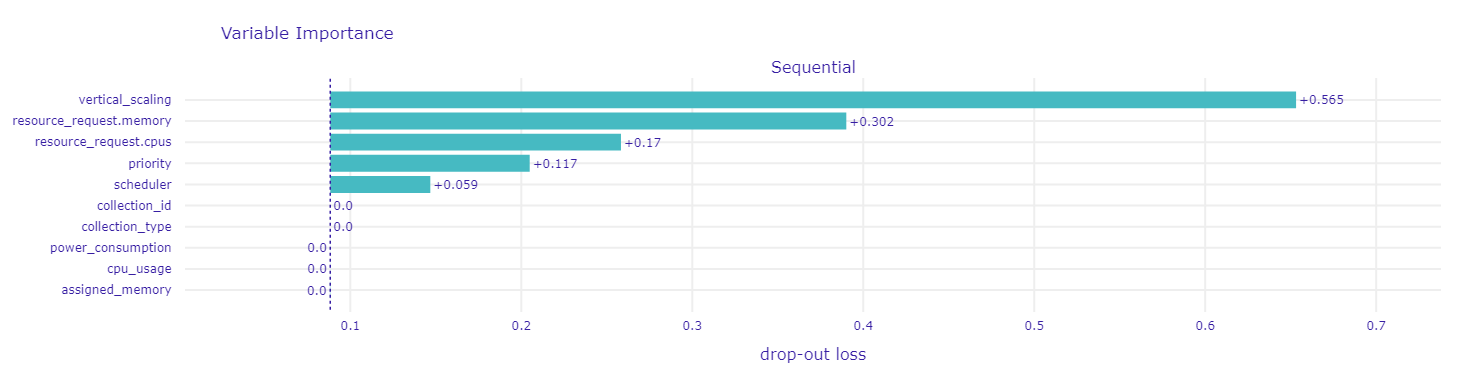

In [87]:
explanation_GRU_SMOTE_train = exp_GRU_SMOTE_train.model_parts()
explanation_GRU_SMOTE_train.result
explanation_GRU_SMOTE_train.plot()

In [88]:
exp_GRU_SMOTE_train.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,0.611328,128.792671,0.0,0.000012,-0.000012,0.000012,Sequential,1
1,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.004663,87.509265,1.0,0.999968,0.000032,0.000032,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002063,87.229200,0.0,0.000013,-0.000013,0.000013,Sequential,3
3,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,0.002058,87.228679,0.0,0.000013,-0.000013,0.000013,Sequential,4
4,4.982169e+11,1.0,0.416916,0.635787,0.0,2.0,1.0,0.003300,0.004447,87.486289,0.0,0.000011,-0.000011,0.000011,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166719,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002272,87.251969,1.0,0.999950,0.000050,0.000050,Sequential,1166720
1166720,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,0.002283,87.253215,1.0,0.999950,0.000050,0.000050,Sequential,1166721
1166721,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,0.003426,87.376855,1.0,0.999968,0.000032,0.000032,Sequential,1166722
1166722,4.984476e+11,1.0,0.428609,-0.159731,0.0,3.0,1.0,0.001957,0.028427,89.900671,1.0,0.999246,0.000754,0.000754,Sequential,1166723


In [89]:
GRU_SMOTE_test = km.load_model('Jobs/GRU/GRU_SMOTE.keras')
exp_GRU_SMOTE_test = dx.Explainer(GRU_SMOTE_test, X_test_SMOTE, Y_test_SMOTE)

Preparation of a new explainer is initiated

  -> data              : 500104 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 500104 values
  -> model_class       : keras.engine.sequential.Sequential (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_tf_regression at 0x000002D212BDC670> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 6.46e-06, mean = 0.507, max = 1.0
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -0.00692, max = 1.0
  -> model_info        : package keras

A new explainer has been created!


In [90]:
exp_GRU_SMOTE_test.model_performance(model_type = 'classification')

,recall,precision,f1,accuracy,auc
Sequential,0.999696,0.98472,0.992151,0.992092,0.998536


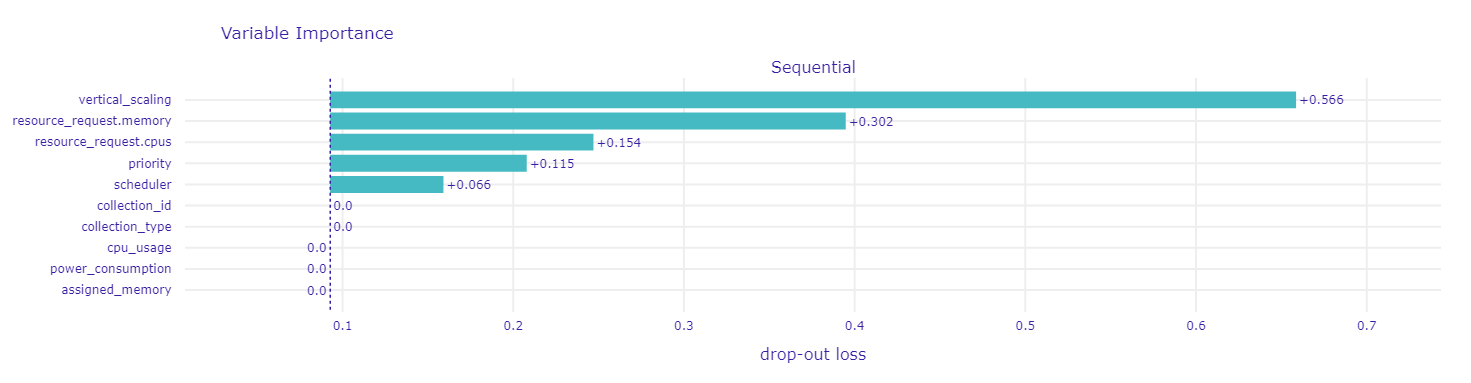

In [91]:
explanation_GRU_SMOTE_test = exp_GRU_SMOTE_test.model_parts()
explanation_GRU_SMOTE_test.result
explanation_GRU_SMOTE_test.plot()

In [92]:
exp_GRU_SMOTE_test.model_diagnostics().result

,collection_id,priority,resource_request.cpus,resource_request.memory,collection_type,vertical_scaling,scheduler,assigned_memory,cpu_usage,power_consumption,y,y_hat,residuals,abs_residuals,label,ids
0,4.980479e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,2.098083e-03,87.233051,1.0,0.999950,0.000050,0.000050,Sequential,1
1,4.963447e+11,1.0,0.416916,2.049133,0.0,1.0,1.0,0.010422,5.584717e-03,87.607161,1.0,0.999950,0.000050,0.000050,Sequential,2
2,4.945463e+11,1.0,-0.613973,0.239532,0.0,2.0,1.0,0.002460,2.060890e-03,87.228992,0.0,0.000013,-0.000013,0.000013,Sequential,3
3,4.953396e+11,1.0,1.884318,2.165943,0.0,2.0,1.0,0.013779,4.572754e-01,120.649518,0.0,0.000012,-0.000012,0.000012,Sequential,4
4,4.982237e+11,1.0,0.186097,1.212256,0.0,2.0,1.0,0.005600,9.536743e-07,87.000110,0.0,0.000782,-0.000782,0.000782,Sequential,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500099,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,4.050255e-03,87.443894,1.0,0.999968,0.000032,0.000032,Sequential,500100
500100,4.599540e+11,1.0,-0.445984,-0.467412,0.0,3.0,1.0,0.003754,3.694534e-03,87.405762,1.0,0.999562,0.000438,0.000438,Sequential,500101
500101,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.962517e-03,87.434499,1.0,0.999968,0.000032,0.000032,Sequential,500102
500102,4.767899e+11,2.0,-0.692554,-0.562505,0.0,3.0,1.0,0.001163,3.477097e-03,87.382396,1.0,0.999968,0.000032,0.000032,Sequential,500103


In [272]:
exp1_WIB_train = exp_LR_train.model_performance(model_type = 'classification')
exp2_WIB_train = exp_DT_train.model_performance(model_type = 'classification')
exp3_WIB_train = exp_RF_train.model_performance(model_type = 'classification')
exp4_WIB_train = exp_GB_train.model_performance(model_type = 'classification')
exp5_WIB_train = exp_XGB_train.model_performance(model_type = 'classification')
exp6_WIB_train = exp_LSTM_train.model_performance(model_type = 'classification')
exp7_WIB_train = exp_GRU_train.model_performance(model_type = 'classification')

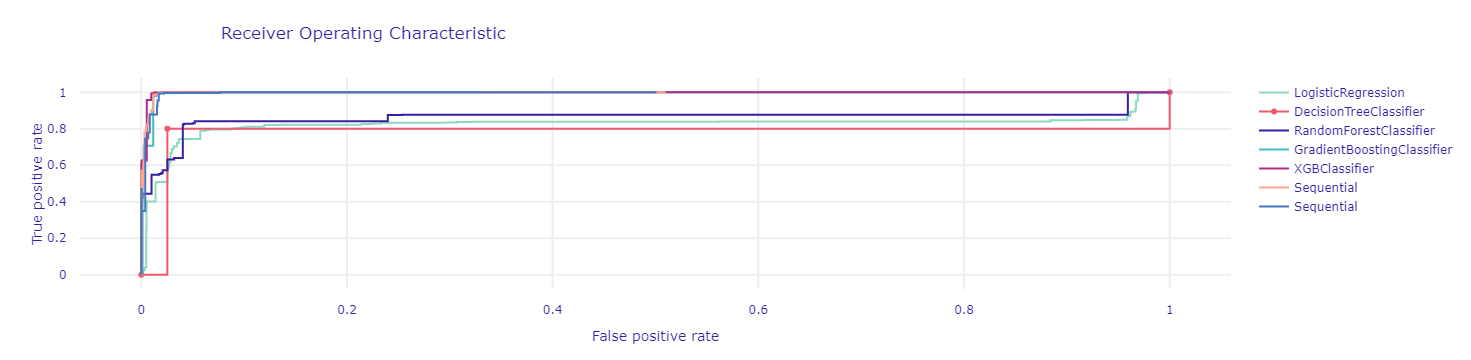

In [279]:
exp1_WIB_train.plot([exp2_WIB_train, exp3_WIB_train, exp4_WIB_train, exp5_WIB_train, exp6_WIB_train, exp7_WIB_train], geom = 'roc')

In [280]:
exp1_WIB_test = exp_LR_test.model_performance(model_type = 'classification')
exp2_WIB_test = exp_DT_test.model_performance(model_type = 'classification')
exp3_WIB_test = exp_RF_test.model_performance(model_type = 'classification')
exp4_WIB_test = exp_GB_test.model_performance(model_type = 'classification')
exp5_WIB_test = exp_XGB_test.model_performance(model_type = 'classification')
exp6_WIB_test = exp_LSTM_test.model_performance(model_type = 'classification')
exp7_WIB_test = exp_GRU_test.model_performance(model_type = 'classification')

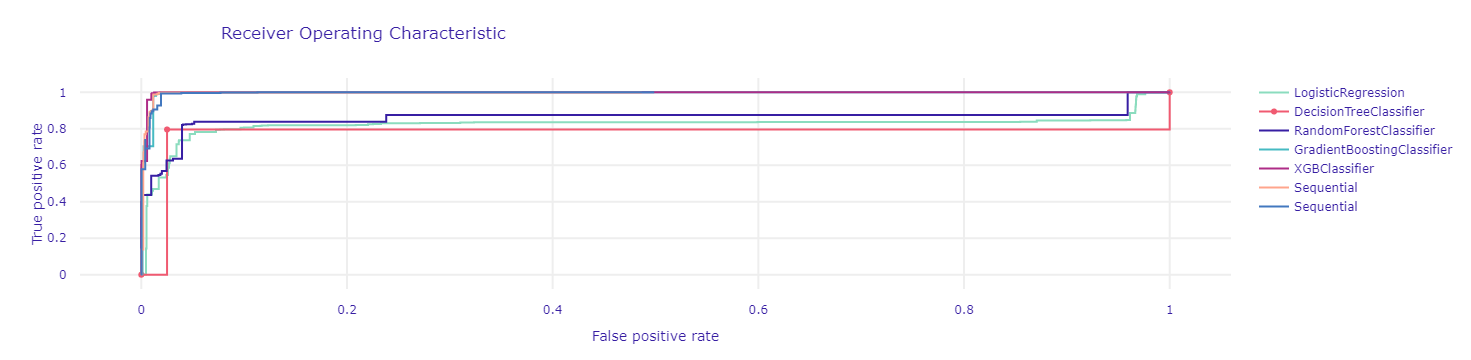

In [281]:
exp1_WIB_test.plot([exp2_WIB_test, exp3_WIB_test, exp4_WIB_test, exp5_WIB_test, exp6_WIB_test, exp7_WIB_test], geom = 'roc')

In [282]:
exp1_RUS_train = exp_LR_RUS_train.model_performance(model_type = 'classification')
exp2_RUS_train = exp_DT_RUS_train.model_performance(model_type = 'classification')
exp3_RUS_train = exp_RF_RUS_train.model_performance(model_type = 'classification')
exp4_RUS_train = exp_GB_RUS_train.model_performance(model_type = 'classification')
exp5_RUS_train = exp_XGB_RUS_train.model_performance(model_type = 'classification')
exp6_RUS_train = exp_LSTM_RUS.model_performance(model_type = 'classification')
exp7_RUS_train = exp_GRU_RUS_train.model_performance(model_type = 'classification')

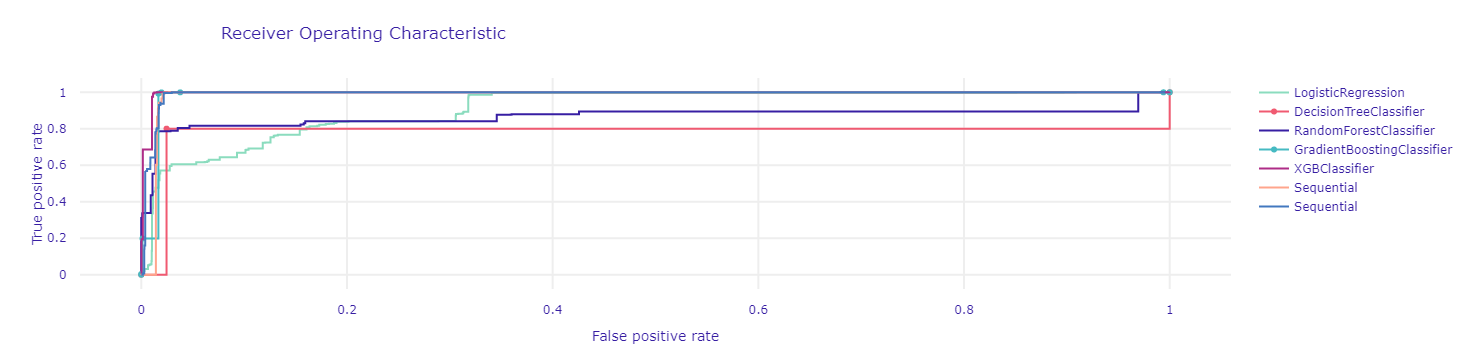

In [283]:
exp1_RUS_train.plot([exp2_RUS_train, exp3_RUS_train, exp4_RUS_train, exp5_RUS_train, exp6_RUS_train, exp7_RUS_train], geom = 'roc')

In [284]:
exp1_RUS_test = exp_LR_RUS_test.model_performance(model_type = 'classification')
exp2_RUS_test = exp_DT_RUS_test.model_performance(model_type = 'classification')
exp3_RUS_test = exp_RF_RUS_test.model_performance(model_type = 'classification')
exp4_RUS_test = exp_GB_RUS_test.model_performance(model_type = 'classification')
exp5_RUS_test = exp_XGB_RUS_test.model_performance(model_type = 'classification')
exp6_RUS_test = exp_LSTM_RUS_test.model_performance(model_type = 'classification')
exp7_RUS_test = exp_GRU_RUS_test.model_performance(model_type = 'classification')

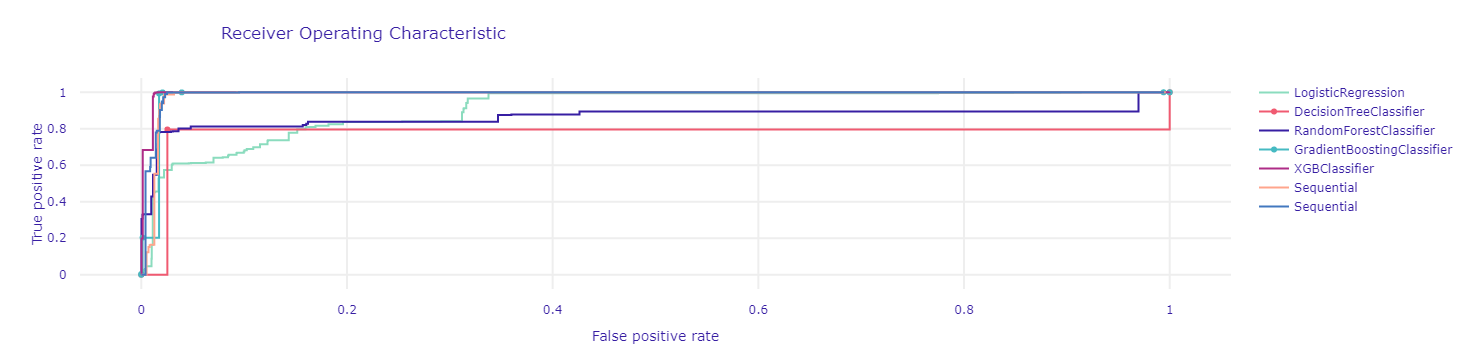

In [285]:
exp1_RUS_test.plot([exp2_RUS_test, exp3_RUS_test, exp4_RUS_test, exp5_RUS_test, exp6_RUS_test, exp7_RUS_test], geom = 'roc')

In [286]:
exp1_ROS_train = exp_LR_ROS_train.model_performance(model_type = 'classification')
exp2_ROS_train = exp_DT_ROS_train.model_performance(model_type = 'classification')
exp3_ROS_train = exp_RF_ROS_train.model_performance(model_type = 'classification')
exp4_ROS_train = exp_GB_ROS_train.model_performance(model_type = 'classification')
exp5_ROS_train = exp_XGB_ROS_train.model_performance(model_type = 'classification')
exp6_ROS_train = exp_LSTM_ROS_train.model_performance(model_type = 'classification')
exp7_ROS_train = exp_GRU_ROS_train.model_performance(model_type = 'classification')

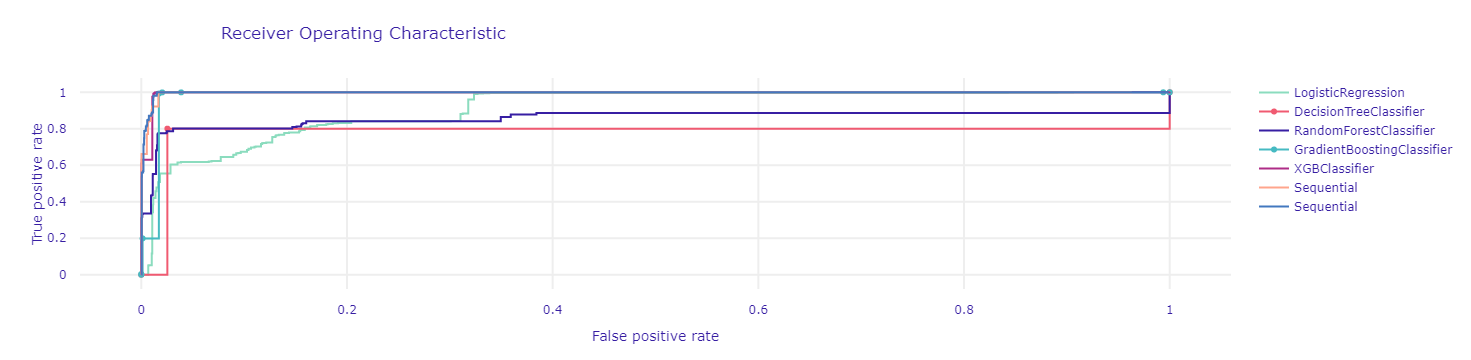

In [287]:
exp1_ROS_train.plot([exp2_ROS_train, exp3_ROS_train, exp4_ROS_train, exp5_ROS_train, exp6_ROS_train, exp7_ROS_train], geom = 'roc')

In [288]:
exp1_ROS_test = exp_LR_ROS_test.model_performance(model_type = 'classification')
exp2_ROS_test = exp_DT_ROS_test.model_performance(model_type = 'classification')
exp3_ROS_test = exp_RF_ROS_test.model_performance(model_type = 'classification')
exp4_ROS_test = exp_GB_ROS_test.model_performance(model_type = 'classification')
exp5_ROS_test = exp_XGB_ROS_test.model_performance(model_type = 'classification')
exp6_ROS_test = exp_LSTM_ROS_test.model_performance(model_type = 'classification')
exp7_ROS_test = exp_GRU_ROS_test.model_performance(model_type = 'classification')

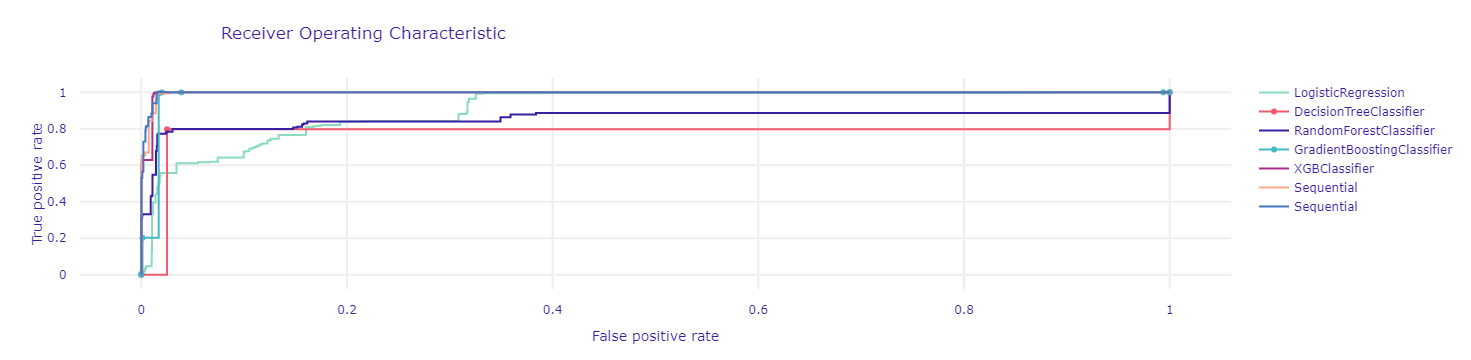

In [289]:
exp1_ROS_test.plot([exp2_ROS_test, exp3_ROS_test, exp4_ROS_test, exp5_ROS_test, exp6_ROS_test, exp7_ROS_test], geom = 'roc')

In [290]:
exp1_SMOTE_train = exp_LR_SMOTE_train.model_performance(model_type = 'classification')
exp2_SMOTE_train = exp_DT_SMOTE_train.model_performance(model_type = 'classification')
exp3_SMOTE_train = exp_RF_SMOTE_train.model_performance(model_type = 'classification')
exp4_SMOTE_train = exp_GB_SMOTE_train.model_performance(model_type = 'classification')
exp5_SMOTE_train = exp_XGB_SMOTE_train.model_performance(model_type = 'classification')
exp6_SMOTE_train = exp_LSTM_SMOTE_train.model_performance(model_type = 'classification')
exp7_SMOTE_train = exp_GRU_SMOTE_train.model_performance(model_type = 'classification')

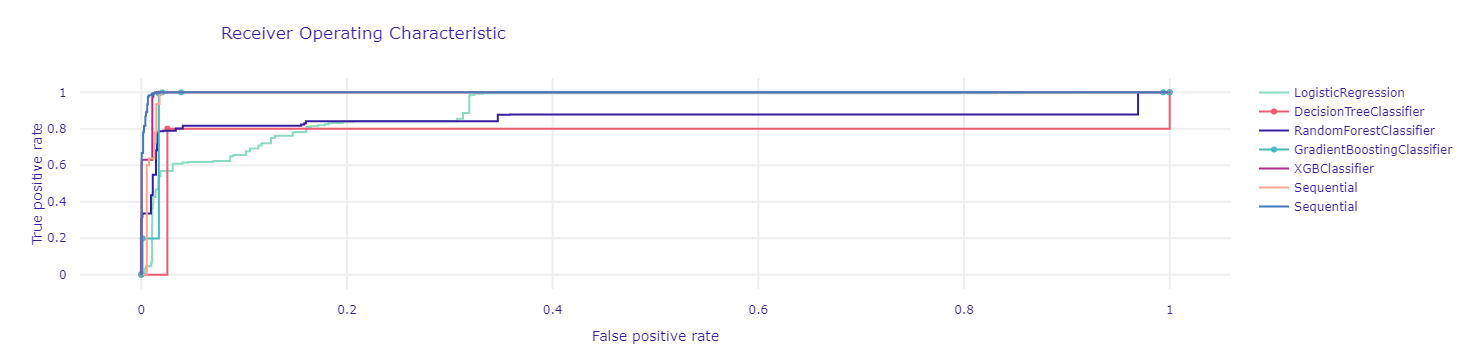

In [291]:
exp1_SMOTE_train.plot([exp2_SMOTE_train, exp3_SMOTE_train, exp4_SMOTE_train, exp5_SMOTE_train, exp6_SMOTE_train, exp7_SMOTE_train], geom = 'roc')

In [292]:
exp1_SMOTE_test = exp_LR_SMOTE_test.model_performance(model_type = 'classification')
exp2_SMOTE_test = exp_DT_SMOTE_test.model_performance(model_type = 'classification')
exp3_SMOTE_test = exp_RF_SMOTE_test.model_performance(model_type = 'classification')
exp4_SMOTE_test = exp_GB_SMOTE_test.model_performance(model_type = 'classification')
exp5_SMOTE_test = exp_XGB_SMOTE_test.model_performance(model_type = 'classification')
exp6_SMOTE_test = exp_LSTM_SMOTE_test.model_performance(model_type = 'classification')
exp7_SMOTE_test = exp_GRU_SMOTE_test.model_performance(model_type = 'classification')

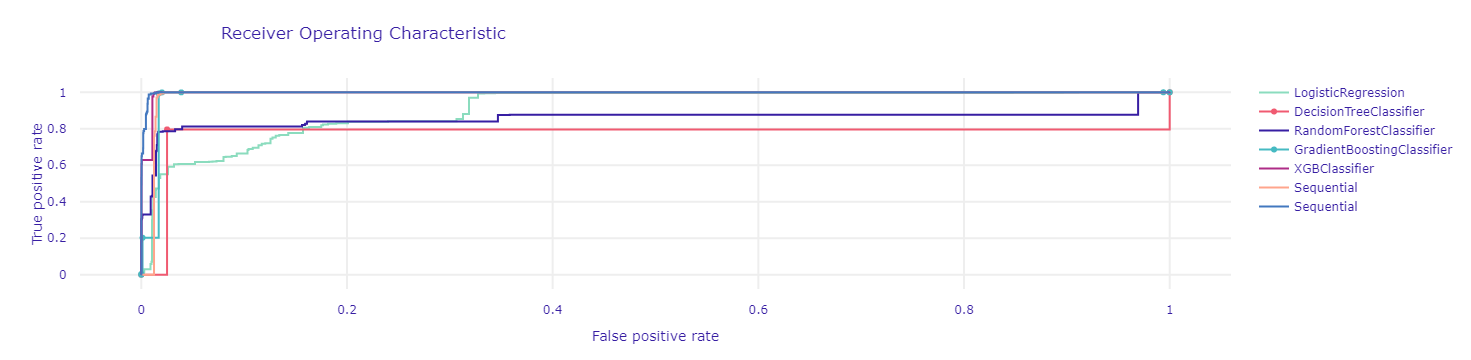

In [293]:
exp1_SMOTE_test.plot([exp2_SMOTE_test, exp3_SMOTE_test, exp4_SMOTE_test, exp5_SMOTE_test, exp6_SMOTE_test, exp7_SMOTE_test], geom = 'roc')